# Surgical Patient Flow Intelligence

- [Architecture](#architecture)
- [0. Environment & Imports](#environment-imports)
- [Database Connection](#database-connection)
  - [Check data of each table](#check-data-each-table)
  - [Check Columns of Each Table](#check-columns-each-table)
- [2. Basic Statistics](#basic-statistics)
  - [Missing Value Percentage](#missing-value-percentage)
- [3. Exploratory Data Analysis](#exploratory-data-analysis)
- [Merge Tables](#merge-tables)
  - [Date Conversion](#date-conversion)
  - [Join Operational Table](#join-operational-table)
  - [Feature Engineering](#feature-engineering)
  - [Identify High Cardinality Features](#high-cardinality-features)
  - [Encoding](#encoding)
  - [Fill Missing Values](#fill-missing-values)
- [Model Building](#model-building)
  - [MODEL 1 - DISCHARGE READINESS](#model-1-discharge-readiness)
  - [Calibrated Model](#calibrated-model)
  - [Prediction & Evaluation](#prediction-evaluation)
  - [Precision-Recall Analysis](#precision-recall-analysis)
  - [FINAL Decision Logic](#final-decision-logic)
  - [Final Output & Analysis](#final-output-analysis)
  - [SHAP Explanation for Discharge Readiness](#shap-explanation-discharge-readiness)
- [MODEL 2 - LOS Prediction](#model-2-los-prediction)
  - [1. Admission LOS Model](#admission-los-model)
    - [Train Model](#train-model-admission)
    - [Evaluation](#evaluation-admission)
  - [PART 2 POST-OPERATIVE MODEL](#part-2-post-operative-model)
    - [2. Post-Operative LOS Model (Dynamic Updates)](#post-operative-los-model-dynamic-updates)
    - [Evaluate](#evaluation-post-operative)
  - [ACTUAL VS PREDICTED](#actual-vs-predicted-los)
  - [Final Summary Evaluation — Length of Stay (LOS) Prediction](#los-final-summary)
- [MODEL 3 - 30-Day Readmission Risk](#model-3-readmission-risk)
  - [top 30 features](#top-30-features-readmission)
  - [Train Test Split](#train-test-split-readmission)
  - [Evaluation](#evaluation-readmission)
  - [Decision Analysis](#decision-analysis-readmission)
  - [Readmission Model — Final Summary](#readmission-model-final-summary)
- [Task 4: Clinical Intervention Recommendations](#task-4-clinical-intervention-recommendations)
  - [Summary of Task 4 Recommendations](#summary-of-task-4-recommendations)

## <a id="architecture"></a> Architecture



**Objective:** Multi-task ML system to predict:

- **Task 1** — Daily discharge readiness (binary classification)
- **Task 2** — Total length of stay (regression)
- **Task 3** — 30-day readmission risk (binary classification)
- **Task 4** — Intervention recommendation (multi-label / rule-augmented)

**Database:** `surgical_predictions.db`  
**Tables:** `patients`, `surgical_encounters`, `daily_clinical_status`, `outcomes`, `hospital_operations_daily`

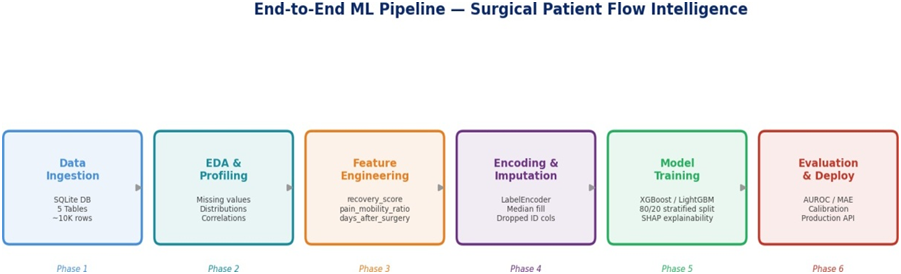

## <a id="environment-imports"></a> 0. Environment & Imports

In [ ]:
# !pip install --upgrade numpy pandas scipy scikit-learn
# !pip install numpy==1.26.4 matplotlib==3.8.4
# !pip install lightgbm
# !pip install --upgrade pandas lightgbm

In [ ]:
import sqlite3
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# from sklearn.ensemble import RandomForestClassifier
# from sklearn.ensemble import RandomForestRegressor
# from lightgbm import LGBMClassifier
# from lightgbm import LGBMRegressor

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    GradientBoostingRegressor, RandomForestRegressor
)
import xgboost as xgb
import shap

from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error,
    roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibratedClassifierCV
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## <a id="database-connection"></a> Database Connection

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

import sqlite3
import pandas as pd

conn = sqlite3.connect("/content/drive/MyDrive/Colab_Projects/Kaizer/surgical_predictions.db")

# Show all tables
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql(query, conn)

print(tables)

Mounted at /content/drive


In [ ]:
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('patients',), ('surgical_encounters',), ('daily_clinical_status',), ('outcomes',), ('hospital_operations_daily',)]


### <a id="check-data-each-table"></a> Check data of each table

In [ ]:
patients_df = pd.read_sql(f"SELECT * FROM patients", conn)
patients_df.head()

,patient_id,mrn,full_name,gender,age,bmi,smoking_status,comorbidity_index,asa_class,insurance_type
0,1,MRN104332,Megan Mcclain,female,55,27.0,never,3,4,self-pay
1,2,MRN600133,Alyssa Gonzalez,male,64,31.6,former,3,3,medicaid
2,3,MRN863794,Abigail Shaffer,female,42,24.3,never,0,3,commercial
3,4,MRN542351,Brent Abbott,female,63,30.5,never,2,3,medicare
4,5,MRN078161,Sandra Montgomery,female,43,25.1,never,2,2,medicaid


In [ ]:
print("- \n")
surgical_encounters_df = pd.read_sql(f"SELECT * FROM surgical_encounters", conn)
surgical_encounters_df.head()

print("- \n")
daily_clinical_status_df = pd.read_sql(f"SELECT * FROM daily_clinical_status", conn)
daily_clinical_status_df.head()

print("- \n")
outcomes_df = pd.read_sql(f"SELECT * FROM outcomes", conn)
outcomes_df.head()

print("- \n")
hospital_operations_daily_df = pd.read_sql(f"SELECT * FROM hospital_operations_daily", conn)
hospital_operations_daily_df.head()

- 



,encounter_id,patient_id,surgery_type,surgery_complexity,admission_date,surgery_date,procedure_duration_min,icu_required,complications_count,pain_score_day1,mobility_score_day1,social_barrier_flag
0,1,1,Appendectomy,low,2025-01-06,2025-01-06,146,0,0,7.6,43.1,0
1,2,2,Cholecystectomy,low,2025-11-11,2025-11-12,74,1,1,5.5,32.7,0
2,3,3,Cholecystectomy,low,2025-12-07,2025-12-07,167,1,0,8.6,49.1,0
3,4,4,Cholecystectomy,low,2025-10-16,2025-10-18,104,0,2,8.3,54.2,0
4,5,5,Cholecystectomy,low,2026-03-07,2026-03-09,117,0,3,6.5,35.3,0


- 



,status_id,encounter_id,status_date,postop_day,vitals_stability_score,pain_score,mobility_score,labs_normalized_score,wound_healing_score,care_plan_complete,discharge_ready_label
0,1,1,2025-01-06,0,41.0,6.8,39.2,45.9,30.4,0,0
1,2,1,2025-01-07,1,49.2,7.3,52.8,42.9,40.8,0,0
2,3,1,2025-01-08,2,60.8,5.8,51.1,52.7,39.6,1,0
3,4,1,2025-01-09,3,73.2,5.9,54.6,59.3,46.7,1,0
4,5,1,2025-01-10,4,70.5,4.7,65.0,76.3,65.2,1,1


- 



,encounter_id,actual_los_days,discharge_ready_day,readmission_30d,readmission_reason,intervention_recommendation
0,1,4,4.0,0,None,Continue standard enhanced recovery after surg...
1,2,10,5.0,0,None,Schedule high-touch follow-up within 72 hours
2,3,6,4.0,0,None,Continue standard enhanced recovery after surg...
3,4,9,4.0,1,Dehydration or poor intake,Initiate daily multidisciplinary complication ...
4,5,10,6.0,0,None,Initiate daily multidisciplinary complication ...


- 



,operation_date,bed_occupancy_pct,avg_turnover_hours,nurse_to_patient_ratio,or_block_utilization_pct,ed_boarding_patients
0,2024-11-20,84.0,3.49,4.69,75.4,21
1,2024-11-21,75.9,4.93,4.64,81.2,15
2,2024-11-22,77.3,3.59,6.05,67.0,23
3,2024-11-23,72.3,6.11,4.35,57.2,11
4,2024-11-24,80.4,3.16,5.04,67.8,11


### <a id="check-columns-each-table"></a> Check Columns of Each Table

In [ ]:
for table in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table} LIMIT 5", conn)
    print(f"\nTable: {table}")
    print(df.columns.tolist())


Table: patients
['patient_id', 'mrn', 'full_name', 'gender', 'age', 'bmi', 'smoking_status', 'comorbidity_index', 'asa_class', 'insurance_type']

Table: surgical_encounters
['encounter_id', 'patient_id', 'surgery_type', 'surgery_complexity', 'admission_date', 'surgery_date', 'procedure_duration_min', 'icu_required', 'complications_count', 'pain_score_day1', 'mobility_score_day1', 'social_barrier_flag']

Table: daily_clinical_status
['status_id', 'encounter_id', 'status_date', 'postop_day', 'vitals_stability_score', 'pain_score', 'mobility_score', 'labs_normalized_score', 'wound_healing_score', 'care_plan_complete', 'discharge_ready_label']

Table: outcomes
['encounter_id', 'actual_los_days', 'discharge_ready_day', 'readmission_30d', 'readmission_reason', 'intervention_recommendation']

Table: hospital_operations_daily
['operation_date', 'bed_occupancy_pct', 'avg_turnover_hours', 'nurse_to_patient_ratio', 'or_block_utilization_pct', 'ed_boarding_patients']


In [ ]:
# Print shape of each table
for table in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table}", conn)
    print(f"Table Name: {table}")
    print(f"Shape: {df.shape}")
    print("-" * 40)

Table Name: patients
Shape: (750, 10)
----------------------------------------
Table Name: surgical_encounters
Shape: (750, 12)
----------------------------------------
Table Name: daily_clinical_status
Shape: (7416, 11)
----------------------------------------
Table Name: outcomes
Shape: (750, 6)
----------------------------------------
Table Name: hospital_operations_daily
Shape: (561, 6)
----------------------------------------


In [ ]:
eev

## <a id="basic-statistics"></a> 2. Basic Statistics

In [ ]:
# ── patients ──────────────────────────────────────────────────────────────────
print("=" * 60)
print("PATIENTS TABLE")
print("=" * 60)
print(patients_df.describe(include="all").T[["count","mean","std","min","max","top","freq"]].dropna(how="all"))
print("\nMissing values:\n", patients_df.isnull().sum()[patients_df.isnull().sum() > 0])

PATIENTS TABLE
                   count       mean        std   min    max           top freq
patient_id         750.0      375.5  216.65064   1.0  750.0           NaN  NaN
mrn                  750        NaN        NaN   NaN    NaN     MRN499390    1
full_name            750        NaN        NaN   NaN    NaN  Daniel Clark    2
gender               750        NaN        NaN   NaN    NaN          male  397
age                750.0  57.873333   16.34675  18.0   90.0           NaN  NaN
bmi                750.0  27.810533   5.459929  17.0   46.8           NaN  NaN
smoking_status       750        NaN        NaN   NaN    NaN         never  379
comorbidity_index  750.0   2.318667   1.647444   0.0    7.0           NaN  NaN
asa_class          750.0      3.176   1.070772   1.0    5.0           NaN  NaN
insurance_type       750        NaN        NaN   NaN    NaN      self-pay  203

Missing values:
 Series([], dtype: int64)


In [ ]:
# patients_df['smoking_status'].value_counts()
# patients_df['smoking_status'].isnull().sum()

In [ ]:
# ── surgical encounters ───────────────────────────────────────────────────────
print("=" * 60)
print("SURGICAL ENCOUNTERS TABLE")
print("=" * 60)
print(surgical_encounters_df.describe(include="all").T[["count","mean","std","min","max"]].dropna(how="all"))
print("\nMissing values:\n", surgical_encounters_df.isnull().sum()[surgical_encounters_df.isnull().sum() > 0])

SURGICAL ENCOUNTERS TABLE
                        count        mean        std   min    max
encounter_id            750.0       375.5  216.65064   1.0  750.0
patient_id              750.0       375.5  216.65064   1.0  750.0
surgery_type              750         NaN        NaN   NaN    NaN
surgery_complexity        750         NaN        NaN   NaN    NaN
admission_date            750         NaN        NaN   NaN    NaN
surgery_date              750         NaN        NaN   NaN    NaN
procedure_duration_min  750.0  145.337333   72.24816  45.0  367.0
icu_required            750.0    0.189333   0.392035   0.0    1.0
complications_count     750.0    0.673333   0.876154   0.0    3.0
pain_score_day1         750.0    7.083067   1.244789   3.5   10.0
mobility_score_day1     750.0   39.027733  10.705539   5.0   74.4
social_barrier_flag     750.0    0.153333   0.360549   0.0    1.0

Missing values:
 Series([], dtype: int64)


In [ ]:
# ── daily clinical status ─────────────────────────────────────────────────────
print("=" * 60)
print("DAILY CLINICAL STATUS TABLE")
print("=" * 60)
print(daily_clinical_status_df.describe().T)
print("\nMissing values:\n", daily_clinical_status_df.isnull().sum()[daily_clinical_status_df.isnull().sum() > 0])

DAILY CLINICAL STATUS TABLE
                         count         mean          std   min      25%  \
status_id               7416.0  3708.500000  2140.959131   1.0  1854.75   
encounter_id            7416.0   378.556904   214.633265   1.0   193.00   
postop_day              7416.0     5.195928     3.995282   0.0     2.00   
vitals_stability_score  7416.0    75.740965    22.357506  12.4    56.10   
pain_score              7416.0     4.599987     2.397376   0.0     2.90   
mobility_score          7416.0    66.120267    22.112779   5.0    49.00   
labs_normalized_score   7416.0    72.443959    24.474496  11.3    51.10   
wound_healing_score     7416.0    67.058239    25.429520   8.0    45.20   
care_plan_complete      7416.0     0.411138     0.492073   0.0     0.00   
discharge_ready_label   7416.0     0.551241     0.497401   0.0     0.00   

                            50%      75%     max  
status_id               3708.50  5562.25  7416.0  
encounter_id             382.00   561.00   7

In [ ]:
# ── outcomes ──────────────────────────────────────────────────────────────────
print("=" * 60)
print("OUTCOMES TABLE")
print("=" * 60)
print(outcomes_df.describe(include="all").T[["count","mean","std","min","max"]].dropna(how="all"))
print("\nRe-admission rate:", outcomes_df["readmission_30d"].mean().round(3))
print("\nIntervention distribution:\n", outcomes_df["intervention_recommendation"].value_counts())

OUTCOMES TABLE
                             count      mean        std  min    max
encounter_id                 750.0     375.5  216.65064  1.0  750.0
actual_los_days              750.0     8.888   3.858753  2.0   20.0
discharge_ready_day          721.0  4.456311   0.950785  2.0    7.0
readmission_30d              750.0  0.265333   0.441805  0.0    1.0
readmission_reason             199       NaN        NaN  NaN    NaN
intervention_recommendation    750       NaN        NaN  NaN    NaN

Re-admission rate: 0.265

Intervention distribution:
 intervention_recommendation
Continue standard enhanced recovery after surgery protocol                                                                                                                                                     323
Schedule high-touch follow-up within 72 hours                                                                                                                                                                  142
Init

In [ ]:
# ── hospital operations ───────────────────────────────────────────────────────
print("=" * 60)
print("HOSPITAL OPERATIONS DAILY")
print("=" * 60)
print(hospital_operations_daily_df.describe().T)

HOSPITAL OPERATIONS DAILY
                          count       mean        std   min    25%    50%  \
bed_occupancy_pct         561.0  82.566845   6.588212  64.1  77.80  82.60   
avg_turnover_hours        561.0   4.602745   0.956135   2.1   3.90   4.59   
nurse_to_patient_ratio    561.0   4.970160   0.717004   2.8   4.49   5.00   
or_block_utilization_pct  561.0  73.342068  11.813077  38.2  65.50  73.40   
ed_boarding_patients      561.0  15.934046   7.959783   0.0  10.00  16.00   

                            75%    max  
bed_occupancy_pct         87.40  99.00  
avg_turnover_hours         5.28   7.38  
nurse_to_patient_ratio     5.41   7.34  
or_block_utilization_pct  81.50  98.00  
ed_boarding_patients      21.00  36.00  


In [ ]:
def basic_eda(df, name):
    print('\n' + '='*50)
    print(f'Dataset: {name}')
    print('='*50)
    print('\nShape:')
    print(df.shape)
    print('\nColumns:')
    print(df.columns.tolist())
    print('\nMissing Values:')
    print(df.isnull().sum())
    print('\nData Types:')
    print(df.dtypes)
    print('\nDuplicate Rows:')
    print(df.duplicated().sum())

basic_eda(patients_df, 'patients')
basic_eda(surgical_encounters_df, 'surgical_encounters')
basic_eda(daily_clinical_status_df, 'daily_clinical_status')
basic_eda(outcomes_df, 'outcomes')
basic_eda(hospital_operations_daily_df, 'hospital_operations_daily')


Dataset: patients

Shape:
(750, 10)

Columns:
['patient_id', 'mrn', 'full_name', 'gender', 'age', 'bmi', 'smoking_status', 'comorbidity_index', 'asa_class', 'insurance_type']

Missing Values:
patient_id           0
mrn                  0
full_name            0
gender               0
age                  0
bmi                  0
smoking_status       0
comorbidity_index    0
asa_class            0
insurance_type       0
dtype: int64

Data Types:
patient_id             int64
mrn                   object
full_name             object
gender                object
age                    int64
bmi                  float64
smoking_status        object
comorbidity_index      int64
asa_class              int64
insurance_type        object
dtype: object

Duplicate Rows:
0

Dataset: surgical_encounters

Shape:
(750, 12)

Columns:
['encounter_id', 'patient_id', 'surgery_type', 'surgery_complexity', 'admission_date', 'surgery_date', 'procedure_duration_min', 'icu_required', 'complications_count', 'p

### <a id="missing-value-percentage"></a> Missing Value Percentage

In [ ]:
def missing_percentage(df):
    missing = pd.DataFrame({
        'column': df.columns,
        'missing_count': df.isnull().sum().values,
        'missing_pct': (df.isnull().sum().values / len(df)) * 100
    })
    return missing.sort_values(by='missing_pct', ascending=False)

missing_percentage(patients_df)
missing_percentage(surgical_encounters_df)
missing_percentage(daily_clinical_status_df)
missing_percentage(outcomes_df)
missing_percentage(hospital_operations_daily_df)

,column,missing_count,missing_pct
0,patient_id,0,0.0
1,mrn,0,0.0
2,full_name,0,0.0
3,gender,0,0.0
4,age,0,0.0
5,bmi,0,0.0
6,smoking_status,0,0.0
7,comorbidity_index,0,0.0
8,asa_class,0,0.0
9,insurance_type,0,0.0


,column,missing_count,missing_pct
0,encounter_id,0,0.0
1,patient_id,0,0.0
2,surgery_type,0,0.0
3,surgery_complexity,0,0.0
4,admission_date,0,0.0
5,surgery_date,0,0.0
6,procedure_duration_min,0,0.0
7,icu_required,0,0.0
8,complications_count,0,0.0
9,pain_score_day1,0,0.0


,column,missing_count,missing_pct
0,status_id,0,0.0
1,encounter_id,0,0.0
2,status_date,0,0.0
3,postop_day,0,0.0
4,vitals_stability_score,0,0.0
5,pain_score,0,0.0
6,mobility_score,0,0.0
7,labs_normalized_score,0,0.0
8,wound_healing_score,0,0.0
9,care_plan_complete,0,0.0


,column,missing_count,missing_pct
4,readmission_reason,551,73.466667
2,discharge_ready_day,29,3.866667
1,actual_los_days,0,0.000000
0,encounter_id,0,0.000000
3,readmission_30d,0,0.000000
5,intervention_recommendation,0,0.000000


,column,missing_count,missing_pct
0,operation_date,0,0.0
1,bed_occupancy_pct,0,0.0
2,avg_turnover_hours,0,0.0
3,nurse_to_patient_ratio,0,0.0
4,or_block_utilization_pct,0,0.0
5,ed_boarding_patients,0,0.0


## <a id="exploratory-data-analysis"></a> 3. Exploratory Data Analysis

Text(0.5, 0.98, 'Patient Demographics & Clinical Baseline')

(array([ 8.,  4.,  4.,  9., 21., 27., 29., 33., 18., 31., 45., 56., 54.,
        48., 60., 35., 28., 48., 41., 39., 28., 21., 16., 17., 30.]),
 array([18.  , 20.88, 23.76, 26.64, 29.52, 32.4 , 35.28, 38.16, 41.04,
        43.92, 46.8 , 49.68, 52.56, 55.44, 58.32, 61.2 , 64.08, 66.96,
        69.84, 72.72, 75.6 , 78.48, 81.36, 84.24, 87.12, 90.  ]),
 <BarContainer object of 25 artists>)

Text(0.5, 1.0, 'Age Distribution')

Text(0.5, 0, 'Age (years)')

Text(0, 0.5, 'Count')

...

Text(0.5, 0, 'ASA Class')

(array([122.,   0., 134.,   0., 167.,   0., 145.,   0., 105.,   0.,  52.,
          0.,  19.,   0.,   6.]),
 array([0.        , 0.46666667, 0.93333333, 1.4       , 1.86666667,
        2.33333333, 2.8       , 3.26666667, 3.73333333, 4.2       ,
        4.66666667, 5.13333333, 5.6       , 6.06666667, 6.53333333,
        7.        ]),
 <BarContainer object of 15 artists>)

Text(0.5, 1.0, 'Comorbidity Index')

Text(0.5, 0, 'Index Score')

FileNotFoundError: [Errno 2] No such file or directory: 'plots/eda_demographics.png'

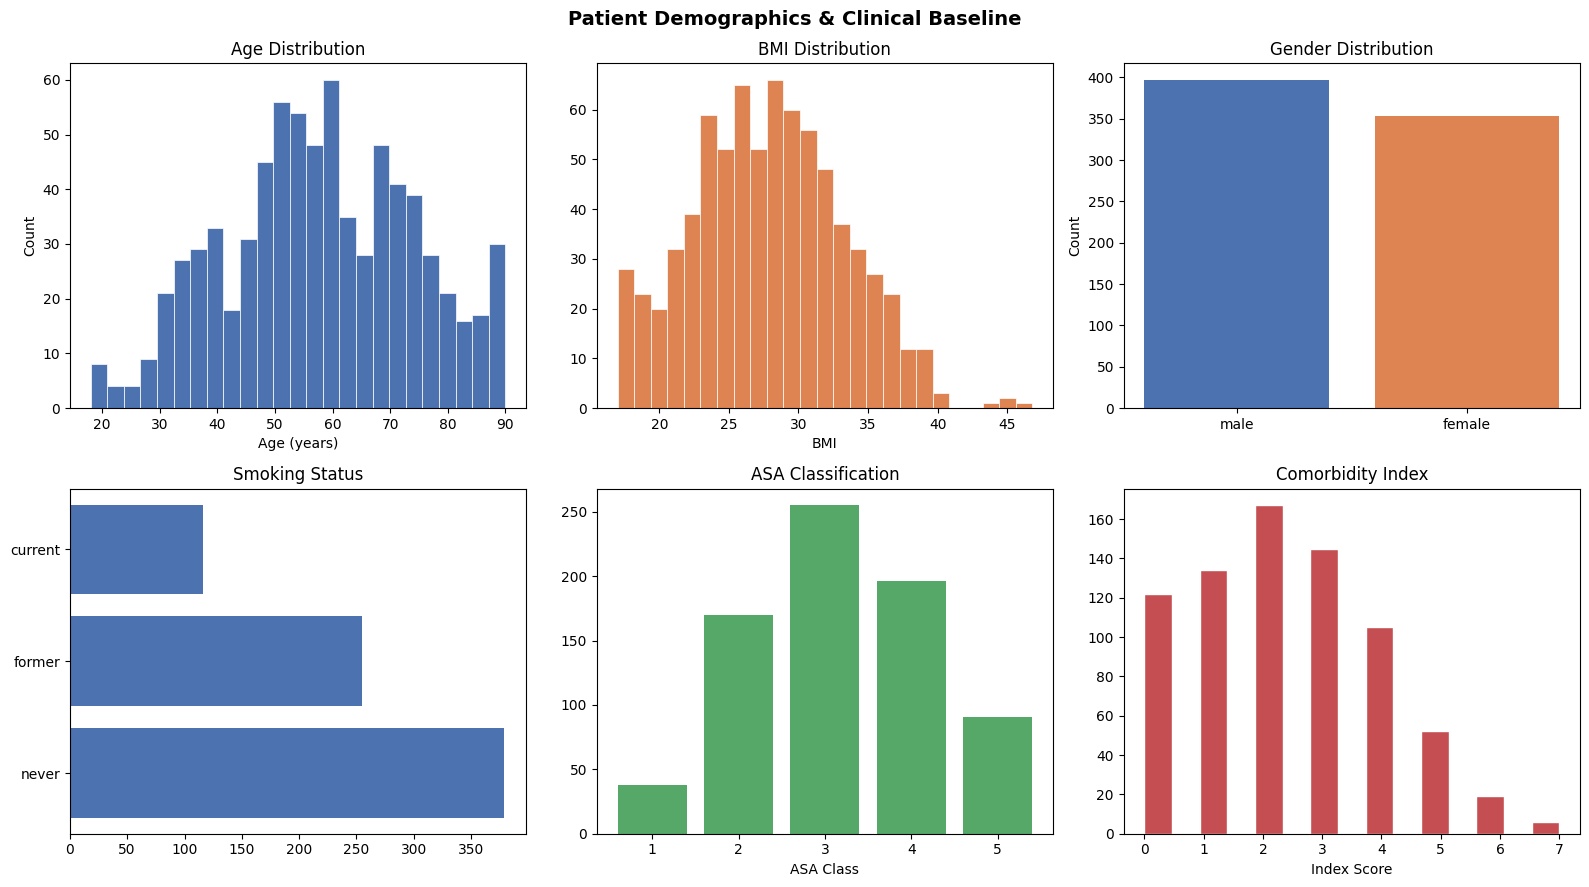

In [ ]:
# ── Patient Demographics ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Patient Demographics & Clinical Baseline", fontsize=14, fontweight="bold")

# Age distribution
axes[0,0].hist(patients_df["age"], bins=25, color="#4C72B0", edgecolor="white", linewidth=0.5)
axes[0,0].set_title("Age Distribution")
axes[0,0].set_xlabel("Age (years)")
axes[0,0].set_ylabel("Count")

# BMI distribution
axes[0,1].hist(patients_df["bmi"], bins=25, color="#DD8452", edgecolor="white", linewidth=0.5)
axes[0,1].set_title("BMI Distribution")
axes[0,1].set_xlabel("BMI")

# Gender split
g_counts = patients_df["gender"].value_counts()
axes[0,2].bar(g_counts.index, g_counts.values, color=["#4C72B0","#DD8452","#55A868"])
axes[0,2].set_title("Gender Distribution")
axes[0,2].set_ylabel("Count")

# Smoking status
s_counts = patients_df["smoking_status"].value_counts()
axes[1,0].barh(s_counts.index, s_counts.values, color="#4C72B0")
axes[1,0].set_title("Smoking Status")

# ASA class
asa_counts = patients_df["asa_class"].value_counts().sort_index()
axes[1,1].bar(asa_counts.index.astype(str), asa_counts.values, color="#55A868")
axes[1,1].set_title("ASA Classification")
axes[1,1].set_xlabel("ASA Class")

# Comorbidity index
axes[1,2].hist(patients_df["comorbidity_index"], bins=15, color="#C44E52", edgecolor="white")
axes[1,2].set_title("Comorbidity Index")
axes[1,2].set_xlabel("Index Score")

plt.tight_layout()
plt.savefig("plots/eda_demographics.png", bbox_inches="tight")
plt.show()
print("Demographics plot saved.")

Text(0.5, 0.98, 'Length of Stay & Discharge Patterns')

(array([15., 20.,  0., 52.,  0., 65., 84.,  0., 75.,  0., 78., 61.,  0.,
        62.,  0., 52., 51.,  0., 34.,  0., 33., 19.,  0., 15.,  0., 16.,
         9.,  0.,  6.,  3.]),
 array([ 2. ,  2.6,  3.2,  3.8,  4.4,  5. ,  5.6,  6.2,  6.8,  7.4,  8. ,
         8.6,  9.2,  9.8, 10.4, 11. , 11.6, 12.2, 12.8, 13.4, 14. , 14.6,
        15.2, 15.8, 16.4, 17. , 17.6, 18.2, 18.8, 19.4, 20. ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Actual Length of Stay')

Text(0.5, 0, 'Days')

<Axes: ylabel='surgery_type'>

...

Text(0.5, 1.0, 'LOS by Surgery Complexity')

Text(0.5, 0, 'Complexity')

Text(0, 0.5, 'LOS Days')

Text(0.5, 1.0, 'LOS by Surgery Complexity')

Text(0.5, 0.98, '')

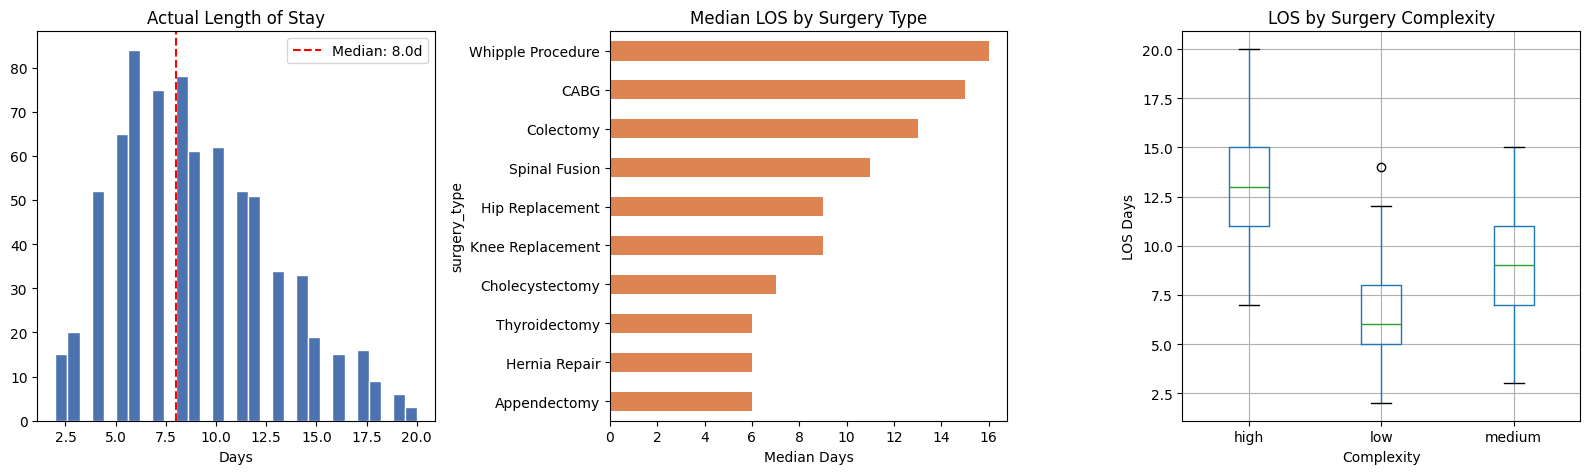

In [ ]:
# ── LOS & Discharge Analysis ─────────────────────────────────────────────────
merged_enc = surgical_encounters_df.merge(outcomes_df, on="encounter_id")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Length of Stay & Discharge Patterns", fontsize=13, fontweight="bold")

# LOS distribution
axes[0].hist(merged_enc["actual_los_days"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].axvline(merged_enc["actual_los_days"].median(), color="red", linestyle="--",
                label=f'Median: {merged_enc["actual_los_days"].median():.1f}d')
axes[0].set_title("Actual Length of Stay")
axes[0].set_xlabel("Days")
axes[0].legend()

# LOS by surgery type
merged_enc.groupby("surgery_type")["actual_los_days"].median().sort_values().plot(
    kind="barh", ax=axes[1], color="#DD8452"
)
axes[1].set_title("Median LOS by Surgery Type")
axes[1].set_xlabel("Median Days")

# LOS by complexity
merged_enc.boxplot(column="actual_los_days", by="surgery_complexity", ax=axes[2])
axes[2].set_title("LOS by Surgery Complexity")
axes[2].set_xlabel("Complexity")
axes[2].set_ylabel("LOS Days")
plt.sca(axes[2])
plt.title("LOS by Surgery Complexity")
plt.suptitle("")

plt.tight_layout()
plt.savefig("eda_los.png", bbox_inches="tight")
plt.show()

Text(0.5, 0.98, '30-Day Readmission Risk Drivers')

<BarContainer object of 5 artists>

Text(0.5, 1.0, 'Readmission Rate by ASA Class')

Text(0, 0.5, 'Rate')

Text(0.5, 0, 'ASA Class')

...

{'whiskers': [<matplotlib.lines.Line2D at 0x7ce4d6ee3890>,
 'caps': [<matplotlib.lines.Line2D at 0x7ce4d6ee3d70>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ce4d6ee3590>,
 'medians': [<matplotlib.lines.Line2D at 0x7ce4d6d14320>,
 'fliers': [<matplotlib.lines.Line2D at 0x7ce4d6d145f0>,
 'means': []}

Text(0.5, 1.0, 'Complications Count vs Readmission')

Text(0, 0.5, 'Complications')

<BarContainer object of 5 artists>

Text(0.5, 1.0, 'Readmission Reasons')

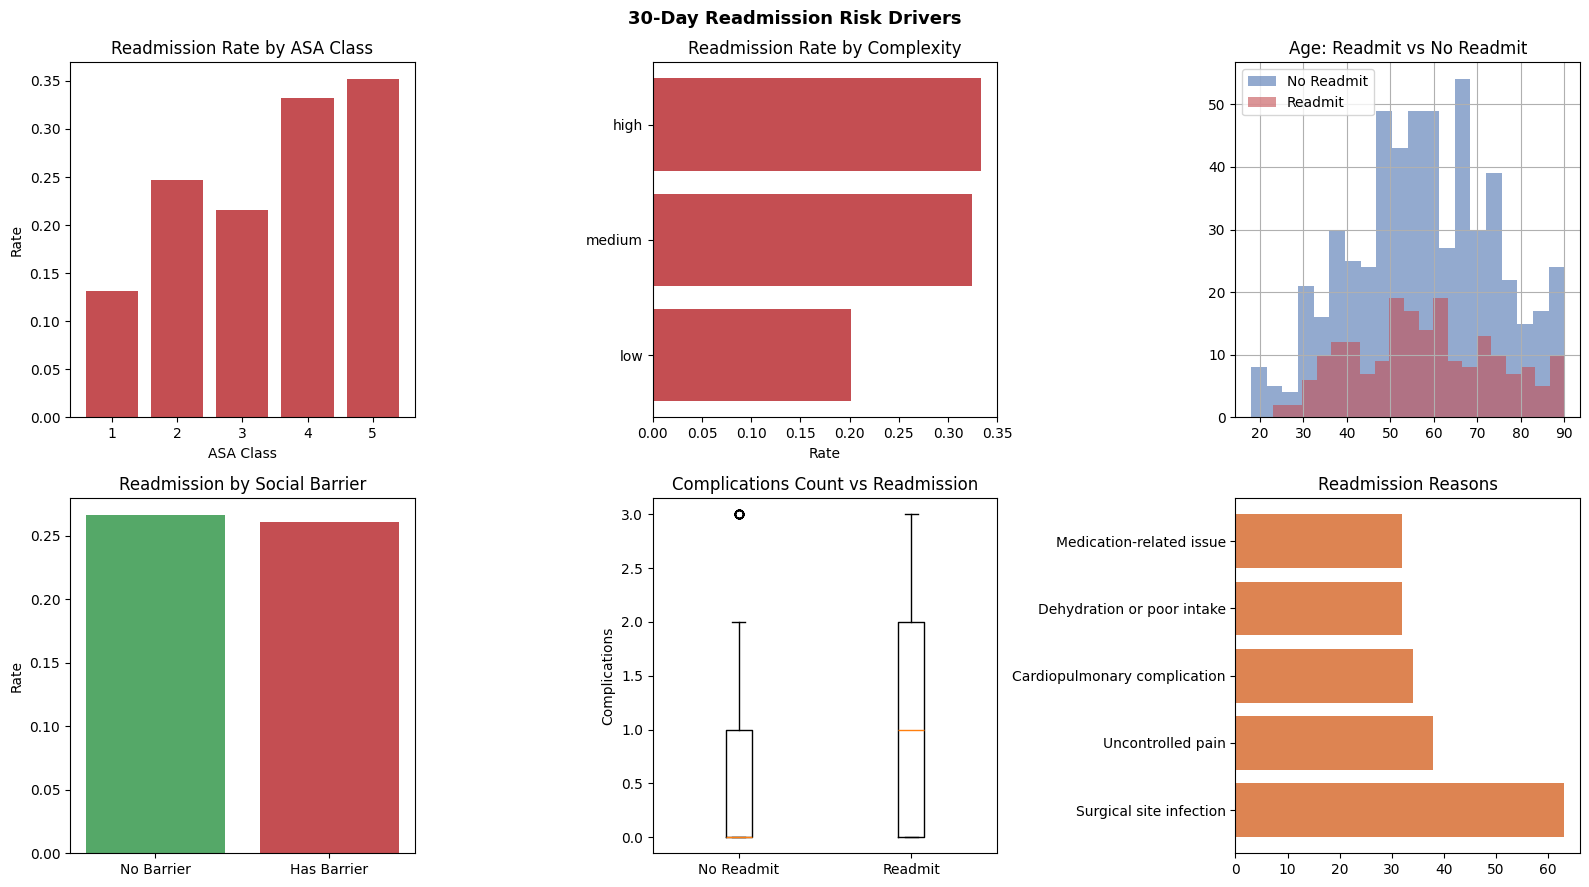

In [ ]:
# ── Readmission Risk Analysis ─────────────────────────────────────────────────
merged_full = patients_df.merge(surgical_encounters_df, on="patient_id").merge(outcomes_df, on="encounter_id")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("30-Day Readmission Risk Drivers", fontsize=13, fontweight="bold")

readm_asa = merged_full.groupby("asa_class")["readmission_30d"].mean()
axes[0,0].bar(readm_asa.index.astype(str), readm_asa.values, color="#C44E52")
axes[0,0].set_title("Readmission Rate by ASA Class")
axes[0,0].set_ylabel("Rate")
axes[0,0].set_xlabel("ASA Class")

readm_comp = merged_full.groupby("surgery_complexity")["readmission_30d"].mean().sort_values()
axes[0,1].barh(readm_comp.index, readm_comp.values, color="#C44E52")
axes[0,1].set_title("Readmission Rate by Complexity")
axes[0,1].set_xlabel("Rate")

merged_full[merged_full["readmission_30d"]==0]["age"].hist(
    bins=20, ax=axes[0,2], alpha=0.6, color="#4C72B0", label="No Readmit")
merged_full[merged_full["readmission_30d"]==1]["age"].hist(
    bins=20, ax=axes[0,2], alpha=0.6, color="#C44E52", label="Readmit")
axes[0,2].set_title("Age: Readmit vs No Readmit")
axes[0,2].legend()

social_readm = merged_full.groupby("social_barrier_flag")["readmission_30d"].mean()
axes[1,0].bar(["No Barrier","Has Barrier"], social_readm.values, color=["#55A868","#C44E52"])
axes[1,0].set_title("Readmission by Social Barrier")
axes[1,0].set_ylabel("Rate")

axes[1,1].boxplot(
    [merged_full[merged_full["readmission_30d"]==0]["complications_count"],
     merged_full[merged_full["readmission_30d"]==1]["complications_count"]],
    labels=["No Readmit","Readmit"]
)
axes[1,1].set_title("Complications Count vs Readmission")
axes[1,1].set_ylabel("Complications")

readm_reasons = outcomes_df[outcomes_df["readmission_30d"]==1]["readmission_reason"].value_counts()
axes[1,2].barh(readm_reasons.index, readm_reasons.values, color="#DD8452")
axes[1,2].set_title("Readmission Reasons")

plt.tight_layout()
plt.savefig("eda_readmission.png", bbox_inches="tight")
plt.show()

Text(0.5, 1.0, 'Average Clinical Score Trajectory (Post-Op Days 0–10)')

Text(0.5, 0, 'Post-Op Day')

Text(0, 0.5, 'Score')

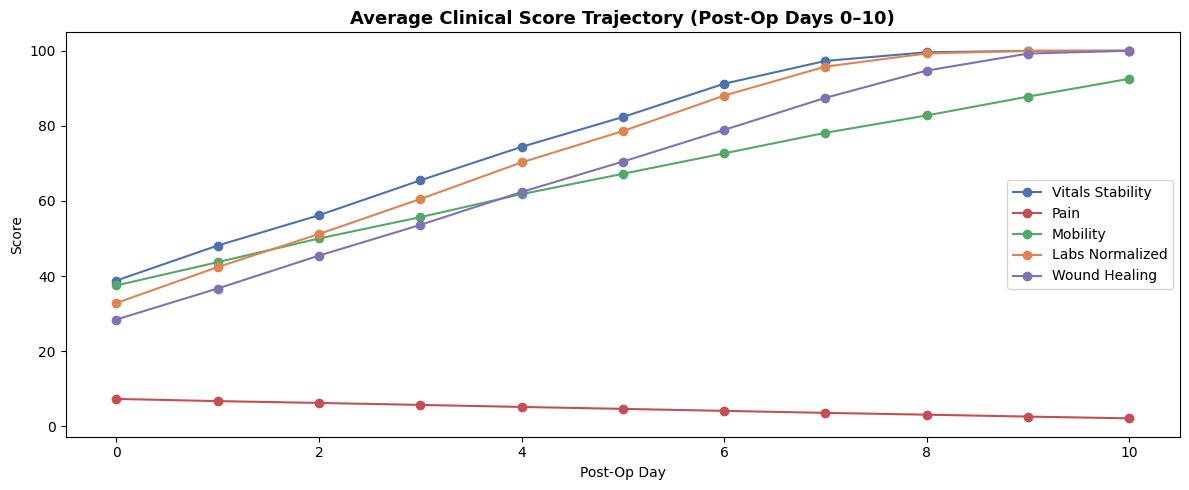

Discharge-ready label distribution by postop day:
postop_day
0     0.000000
1     0.000000
2     0.004000
3     0.140136
4     0.532867
5     0.847662
6     0.976589
7     1.000000
8     1.000000
9     1.000000
10    1.000000
11    1.000000
12    1.000000
13    1.000000
14    1.000000
15    1.000000
16    1.000000
17    1.000000
18    1.000000
19    1.000000
20    1.000000
Name: discharge_ready_label, dtype: float64


In [ ]:
# ── Daily Clinical Trajectory Analysis ────────────────────────────────────────
daily_merged = daily_clinical_status_df.merge(
    surgical_encounters_df[["encounter_id","patient_id"]], on="encounter_id"
).merge(outcomes_df[["encounter_id","readmission_30d","actual_los_days"]], on="encounter_id")

traj_cols = ["vitals_stability_score","pain_score","mobility_score",
             "labs_normalized_score","wound_healing_score"]
traj = daily_merged[daily_merged["postop_day"] <= 10].groupby("postop_day")[traj_cols].mean()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#4C72B0","#C44E52","#55A868","#DD8452","#8172B3"]
for col, c in zip(traj_cols, colors):
    ax.plot(traj.index, traj[col], marker="o", label=col.replace("_score","").replace("_"," ").title(), color=c)

ax.set_title("Average Clinical Score Trajectory (Post-Op Days 0–10)", fontsize=13, fontweight="bold")
ax.set_xlabel("Post-Op Day")
ax.set_ylabel("Score")
ax.legend(loc="center right")
plt.tight_layout()
plt.savefig("eda_trajectory.png", bbox_inches="tight")
plt.show()

print("Discharge-ready label distribution by postop day:")
print(daily_clinical_status_df.groupby("postop_day")["discharge_ready_label"].mean())

Text(0.5, 0.98, 'Hospital Operational Trends Over Time')

Text(0, 0.5, 'Bed Occupancy %')

Text(0, 0.5, 'Nurse : Patient Ratio')

Text(0, 0.5, 'ED Boarding Patients')

Text(0.5, 0, 'Date')

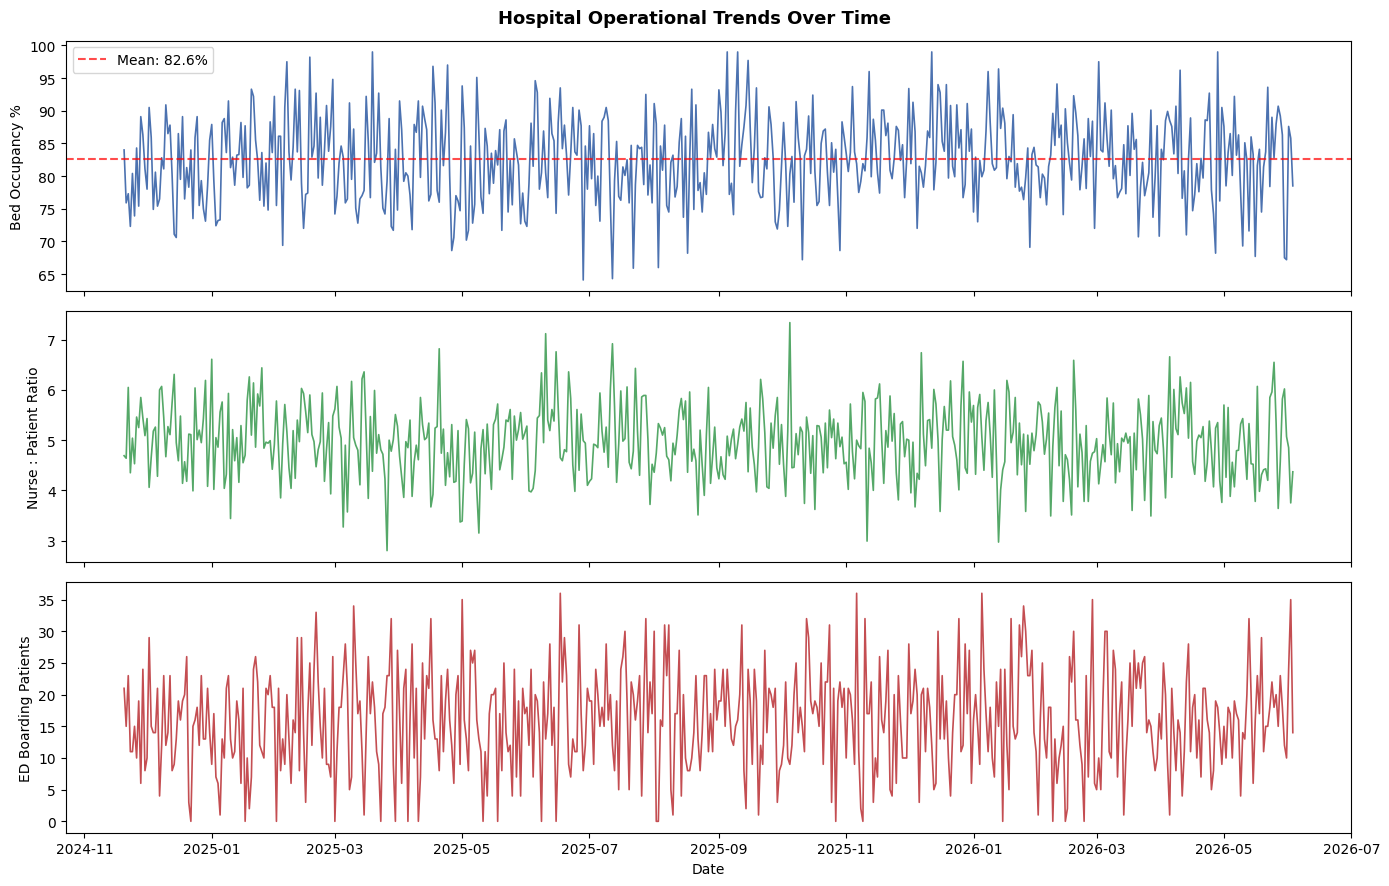

In [ ]:
# ── Hospital Operations ───────────────────────────────────────────────────────
hospital_operations_daily_df["operation_date"] = pd.to_datetime(hospital_operations_daily_df["operation_date"])
ops_daily_sorted = hospital_operations_daily_df.sort_values("operation_date")

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle("Hospital Operational Trends Over Time", fontsize=13, fontweight="bold")

axes[0].plot(ops_daily_sorted["operation_date"], ops_daily_sorted["bed_occupancy_pct"],
             color="#4C72B0", linewidth=1.2)
axes[0].axhline(ops_daily_sorted["bed_occupancy_pct"].mean(), color="red",
                linestyle="--", alpha=0.7, label=f'Mean: {ops_daily_sorted["bed_occupancy_pct"].mean():.1f}%')
axes[0].set_ylabel("Bed Occupancy %")
axes[0].legend()

axes[1].plot(ops_daily_sorted["operation_date"], ops_daily_sorted["nurse_to_patient_ratio"],
             color="#55A868", linewidth=1.2)
axes[1].set_ylabel("Nurse : Patient Ratio")

axes[2].plot(ops_daily_sorted["operation_date"], ops_daily_sorted["ed_boarding_patients"],
             color="#C44E52", linewidth=1.2)
axes[2].set_ylabel("ED Boarding Patients")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.savefig("eda_operations.png", bbox_inches="tight")
plt.show()

## <a id="merge-tables"></a> Merge Tables

In [ ]:
master_df = daily_clinical_status_df.merge(
    surgical_encounters_df,
    on='encounter_id',
    how='left'
)
master_df = master_df.merge(
    patients_df,
    on='patient_id',
    how='left'
)
master_df = master_df.merge(
    outcomes_df,
    on='encounter_id',
    how='left'
)
master_df.shape
list(master_df.columns)

(7416, 36)

['status_id',
 'encounter_id',
 'status_date',
 'postop_day',
 'vitals_stability_score',
 'pain_score',
 'mobility_score',
 'labs_normalized_score',
 'wound_healing_score',
 'care_plan_complete',
 'discharge_ready_label',
 'patient_id',
 'surgery_type',
 'surgery_complexity',
 'admission_date',
 'surgery_date',
 'procedure_duration_min',
 'icu_required',
 'complications_count',
 'pain_score_day1',
 'mobility_score_day1',
 'social_barrier_flag',
 'mrn',
 'full_name',
 'gender',
 'age',
 'bmi',
 'smoking_status',
 'comorbidity_index',
 'asa_class',
 'insurance_type',
 'actual_los_days',
 'discharge_ready_day',
 'readmission_30d',
 'readmission_reason',
 'intervention_recommendation']

### <a id="date-conversion"></a> Date Conversion

In [ ]:
master_df['status_date'] = pd.to_datetime(master_df['status_date'])
master_df['admission_date'] = pd.to_datetime(master_df['admission_date'])
master_df['surgery_date'] = pd.to_datetime(master_df['surgery_date'])
hospital_operations_daily_df['operation_date'] = pd.to_datetime(
    hospital_operations_daily_df['operation_date']
)

### <a id="join-operational-table"></a> Join Operational Table

In [ ]:
master_df = master_df.merge(
    hospital_operations_daily_df,
    left_on='status_date',
    right_on='operation_date',
    how='left'
)
master_df.shape

(7416, 42)

### <a id="feature-engineering"></a> Feature Engineering

In [ ]:
master_df['length_from_admission'] = (
    master_df['status_date'] - master_df['admission_date']
).dt.days

master_df['days_after_surgery'] = (
    master_df['status_date'] - master_df['surgery_date']
).dt.days

master_df['is_weekend'] = master_df['status_date'].dt.weekday.isin([5,6]).astype(int)

master_df['pain_mobility_ratio'] = (
    master_df['pain_score'] / (master_df['mobility_score'] + 1)
)

master_df['recovery_score'] = (
    master_df['mobility_score'] +
    master_df['vitals_stability_score'] +
    master_df['labs_normalized_score'] +
    master_df['wound_healing_score']
)

date_cols = [
    'status_date',
    'admission_date',
    'surgery_date',
    'operation_date'
]

In [ ]:
master_df[date_cols]
master_df.drop(
    columns=date_cols,
    inplace=True
)

,status_date,admission_date,surgery_date,operation_date
0,2025-01-06,2025-01-06,2025-01-06,2025-01-06
1,2025-01-07,2025-01-06,2025-01-06,2025-01-07
2,2025-01-08,2025-01-06,2025-01-06,2025-01-08
3,2025-01-09,2025-01-06,2025-01-06,2025-01-09
4,2025-01-10,2025-01-06,2025-01-06,2025-01-10
...,...,...,...,...
7411,2025-01-12,2025-01-01,2025-01-01,2025-01-12
7412,2025-01-13,2025-01-01,2025-01-01,2025-01-13
7413,2025-01-14,2025-01-01,2025-01-01,2025-01-14
7414,2025-01-15,2025-01-01,2025-01-01,2025-01-15


### <a id="high-cardinality-features"></a> Identify High Cardinality Features

In [ ]:
for col in master_df.columns:
    if master_df[col].dtype == 'object' or master_df[col].nunique() > 100:
        print(f"Column '{col}': {master_df[col].nunique()} unique values")

Column 'status_id': 7416 unique values
Column 'encounter_id': 750 unique values
Column 'vitals_stability_score': 739 unique values
Column 'pain_score': 101 unique values
Column 'mobility_score': 845 unique values
Column 'labs_normalized_score': 801 unique values
Column 'wound_healing_score': 847 unique values
Column 'patient_id': 750 unique values
Column 'surgery_type': 10 unique values
Column 'surgery_complexity': 3 unique values
Column 'procedure_duration_min': 237 unique values
Column 'mobility_score_day1': 349 unique values
Column 'mrn': 750 unique values
Column 'full_name': 741 unique values
Column 'gender': 2 unique values
Column 'bmi': 212 unique values
Column 'smoking_status': 3 unique values
Column 'insurance_type': 4 unique values
Column 'readmission_reason': 5 unique values
Column 'intervention_recommendation': 18 unique values
Column 'bed_occupancy_pct': 219 unique values
Column 'avg_turnover_hours': 286 unique values
Column 'nurse_to_patient_ratio': 246 unique values
Colum

In [ ]:
high_cardinality_cols = [
    'status_id',
    # 'encounter_id',
    'mrn',
    'full_name',
    'readmission_reason',
    'intervention_recommendation',
    'patient_id',
    'icu_required',
    # 'readmission_30d',
    'days_after_surgery',
    'is_weekend'
]
master_df.drop(
    columns=high_cardinality_cols,
    inplace=True
)
print(master_df.shape)
master_df.head()

(7416, 34)


,encounter_id,postop_day,vitals_stability_score,pain_score,mobility_score,labs_normalized_score,wound_healing_score,care_plan_complete,discharge_ready_label,surgery_type,...,discharge_ready_day,readmission_30d,bed_occupancy_pct,avg_turnover_hours,nurse_to_patient_ratio,or_block_utilization_pct,ed_boarding_patients,length_from_admission,pain_mobility_ratio,recovery_score
0,1,0,41.0,6.8,39.2,45.9,30.4,0,0,Appendectomy,...,4.0,0,88.2,2.84,5.76,57.3,13,0,0.169154,156.5
1,1,1,49.2,7.3,52.8,42.9,40.8,0,0,Appendectomy,...,4.0,0,88.8,4.62,4.04,88.9,10,1,0.135688,185.7
2,1,2,60.8,5.8,51.1,52.7,39.6,1,0,Appendectomy,...,4.0,0,83.6,4.93,4.32,80.4,21,2,0.111324,204.2
3,1,3,73.2,5.9,54.6,59.3,46.7,1,0,Appendectomy,...,4.0,0,91.5,5.45,5.93,83.5,23,3,0.106115,233.8
4,1,4,70.5,4.7,65.0,76.3,65.2,1,1,Appendectomy,...,4.0,0,81.3,3.56,3.44,72.8,13,4,0.071212,277.0


In [ ]:
v

NameError: name 'v' is not defined

### <a id="encoding"></a> Encoding

In [ ]:
cat_cols = master_df.select_dtypes(include='object').columns
cat_cols

cat_cols = master_df.select_dtypes(include='object').columns
encoded_df = pd.get_dummies(master_df[cat_cols], drop_first=False)

# Combine back with numerical columns
master_df = pd.concat([master_df.drop(columns=cat_cols), encoded_df], axis=1)

Index(['surgery_type', 'surgery_complexity', 'gender', 'smoking_status',
       'insurance_type'],
      dtype='object')

In [ ]:
master_df.shape

(7416, 51)

In [ ]:
master_df.head()

,encounter_id,postop_day,vitals_stability_score,pain_score,mobility_score,labs_normalized_score,wound_healing_score,care_plan_complete,discharge_ready_label,procedure_duration_min,...,surgery_complexity_medium,gender_female,gender_male,smoking_status_current,smoking_status_former,smoking_status_never,insurance_type_commercial,insurance_type_medicaid,insurance_type_medicare,insurance_type_self-pay
0,1,0,41.0,6.8,39.2,45.9,30.4,0,0,146,...,False,True,False,False,False,True,False,False,False,True
1,1,1,49.2,7.3,52.8,42.9,40.8,0,0,146,...,False,True,False,False,False,True,False,False,False,True
2,1,2,60.8,5.8,51.1,52.7,39.6,1,0,146,...,False,True,False,False,False,True,False,False,False,True
3,1,3,73.2,5.9,54.6,59.3,46.7,1,0,146,...,False,True,False,False,False,True,False,False,False,True
4,1,4,70.5,4.7,65.0,76.3,65.2,1,1,146,...,False,True,False,False,False,True,False,False,False,True


### <a id="fill-missing-values"></a> Fill Missing Values

In [ ]:
for col in master_df.columns:
    if master_df[col].dtype != 'object':
        master_df[col] = master_df[col].fillna(master_df[col].median())

In [ ]:
numeric_cols = [
    'vitals_stability_score', 'pain_score', 'mobility_score',
    'labs_normalized_score', 'wound_healing_score'
]
master_df[numeric_cols] = master_df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [ ]:
master_df_2 = master_df.copy()

In [ ]:
drop_cols=['recovery_score',
    'discharge_ready_day',
    'actual_los_days',
    'length_from_admission',
    'vitals_stability_score',
    'care_plan_complete',
    'postop_day']
master_df = master_df.drop(drop_cols, axis=1)

## <a id="model-building"></a> Model Building

### <a id="model-1-discharge-readiness"></a> MODEL 1 - DISCHARGE READINESS

In [ ]:
master_df

,encounter_id,pain_score,mobility_score,labs_normalized_score,wound_healing_score,discharge_ready_label,procedure_duration_min,complications_count,pain_score_day1,mobility_score_day1,...,surgery_complexity_medium,gender_female,gender_male,smoking_status_current,smoking_status_former,smoking_status_never,insurance_type_commercial,insurance_type_medicaid,insurance_type_medicare,insurance_type_self-pay
0,1,6.8,39.2,45.9,30.4,0,146,0,7.6,43.1,...,False,True,False,False,False,True,False,False,False,True
1,1,7.3,52.8,42.9,40.8,0,146,0,7.6,43.1,...,False,True,False,False,False,True,False,False,False,True
2,1,5.8,51.1,52.7,39.6,0,146,0,7.6,43.1,...,False,True,False,False,False,True,False,False,False,True
3,1,5.9,54.6,59.3,46.7,0,146,0,7.6,43.1,...,False,True,False,False,False,True,False,False,False,True
4,1,4.7,65.0,76.3,65.2,1,146,0,7.6,43.1,...,False,True,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7411,750,1.1,100.0,100.0,100.0,1,236,0,6.4,40.1,...,False,False,True,False,False,True,True,False,False,False
7412,750,0.0,100.0,100.0,100.0,1,236,0,6.4,40.1,...,False,False,True,False,False,True,True,False,False,False
7413,750,0.0,100.0,100.0,100.0,1,236,0,6.4,40.1,...,False,False,True,False,False,True,True,False,False,False
7414,750,0.0,100.0,100.0,100.0,1,236,0,6.4,40.1,...,False,False,True,False,False,True,True,False,False,False


In [ ]:
master_df['discharge_ready_label'].value_counts(normalize=True)

,proportion
discharge_ready_label,
1,0.551241
0,0.448759


In [ ]:


discharge_model = master_df.copy()

X = discharge_model.drop(
    columns=['discharge_ready_label']
)
y = discharge_model['discharge_ready_label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_train.shape
X_test.shape
y_train.shape
y_test.shape

(5191, 43)

(2225, 43)

(5191,)

(2225,)

In [ ]:
from lightgbm import LGBMClassifier

# model = LGBMClassifier(
#     n_estimators=200,
#     learning_rate=0.05,
#     max_depth=10,
#     random_state=42
# )
# model.fit(X_train, y_train)

model = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# from xgboost import XGBClassifier
# model = XGBClassifier(
#     n_estimators=200,
#     learning_rate=0.05,
#     max_depth=6,
#     random_state=42,
#     eval_metric='logloss'
# )

model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2861, number of negative: 2330
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000976 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3257
[LightGBM] [Info] Number of data points in the train set: 5191, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.551146 -> initscore=0.205303
[LightGBM] [Info] Start training from score 0.205303


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03, n_estimators=400,
               random_state=42, subsample=0.8)

### <a id="calibrated-model"></a> Calibrated Model

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2288, number of negative: 1864
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000552 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3234
[LightGBM] [Info] Number of data points in the train set: 4152, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.551060 -> initscore=0.204953
[LightGBM] [Info] Start training from score 0.204953
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2289, number of negative: 1864
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000559 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise

CalibratedClassifierCV(estimator=LGBMClassifier(colsample_bytree=0.8,
                                                learning_rate=0.03,
                                                n_estimators=400,
                                                random_state=42,
                                                subsample=0.8),
                       method='isotonic')

<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'Predicted Probability')

Text(0, 0.5, 'Actual Probability')

Text(0.5, 1.0, 'Calibration Curve (Discharge Readiness Model)')

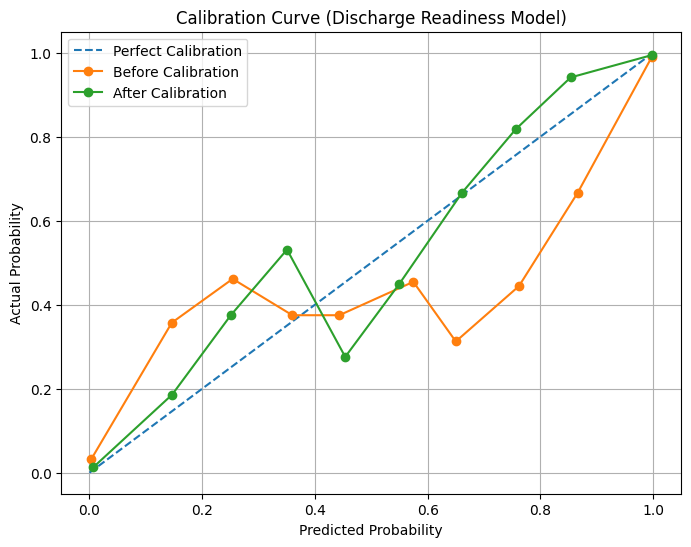

In [ ]:
cal_model = CalibratedClassifierCV(model, method='isotonic')
cal_model.fit(X_train, y_train)

# Raw model probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

# If using calibrated model
y_calibrated = cal_model.predict_proba(X_test)[:, 1]

# For original model
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

# For calibrated model
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_calibrated, n_bins=10)

plt.figure(figsize=(8, 6))
# Perfect calibration line
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')
# Original model
plt.plot(prob_pred, prob_true, marker='o', label='Before Calibration')
# Calibrated model
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label='After Calibration')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Probability')
plt.title('Calibration Curve (Discharge Readiness Model)')
plt.legend()
plt.grid()
plt.show()

### <a id="prediction-evaluation"></a> Prediction & Evaluation

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

# Probabilities
y_prob = model.predict_proba(X_test)[:, 1]
y_calibrated = cal_model.predict_proba(X_test)[:, 1]

# Use calibrated probs for classification
y_pred = (y_calibrated >= 0.5).astype(int)

print("TASK A — Discharge Readiness")
print(f"AUROC : {roc_auc_score(y_test, y_prob):.4f}")
print(f"AUPRC : {average_precision_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Not Ready", "Ready"]))

print(f"\nCalibrated AUROC : {roc_auc_score(y_test, y_calibrated):.4f}")
print(f"Calibrated AUPRC : {average_precision_score(y_test, y_calibrated):.4f}")

TASK A — Discharge Readiness
AUROC : 0.9941
AUPRC : 0.9954

Classification Report:

              precision    recall  f1-score   support

   Not Ready       0.94      0.96      0.95       998
       Ready       0.96      0.95      0.96      1227

    accuracy                           0.96      2225
   macro avg       0.95      0.96      0.95      2225
weighted avg       0.96      0.96      0.96      2225


Calibrated AUROC : 0.9942
Calibrated AUPRC : 0.9955


### <a id="precision-recall-analysis"></a> Precision-Recall Analysis

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_calibrated)

target_precision = 0.98
for p, r, t in zip(precision, recall, thresholds):
    if p >= target_precision:
        print("\nPR-Based Threshold Insight:")
        print("Threshold:", round(t, 3))
        print("Precision:", round(p, 3), "Recall:", round(r, 3))
        break


PR-Based Threshold Insight:
Threshold: 0.587
Precision: 0.981 Recall: 0.945


### <a id="final-decision-logic"></a> FINAL Decision Logic

In [ ]:
def discharge_decision(prob):
    # High safety threshold (critical)
    if prob >= 0.85:
        return "Discharge"

    # Review zone (clinical judgment)
    elif prob >= 0.5:
        return "Review"

    # Not ready
    else:
        return "Not Ready"

test_df = X_test.copy()
test_df['probability'] = y_calibrated
test_df['decision'] = test_df['probability'].apply(discharge_decision)

### <a id="final-output-analysis"></a> Final Output & Analysis

In [ ]:
# Sample output
print(test_df[['probability', 'decision']].head())

# Decision distribution
print("\nDecision Distribution:")
print(test_df['decision'].value_counts())

# Confusion by decision
print("\nDecision vs Actual:")
print(pd.crosstab(test_df['decision'], y_test))

      probability   decision
2965     0.000000  Not Ready
1457     0.350235  Not Ready
3379     0.000000  Not Ready
5887     0.142645  Not Ready
7103     1.000000  Discharge

Decision Distribution:
decision
Discharge    1103
Not Ready    1010
Review        112
Name: count, dtype: int64

Decision vs Actual:
discharge_ready_label    0     1
decision                        
Discharge                7  1096
Not Ready              954    56
Review                  37    75


<Figure size 600x500 with 0 Axes>

<Axes: xlabel='discharge_ready_label', ylabel='decision'>

Text(0.5, 1.0, 'Decision vs Actual')

Text(0.5, 25.722222222222214, 'Actual (0 = Not Ready, 1 = Ready)')

Text(45.722222222222214, 0.5, 'Decision')

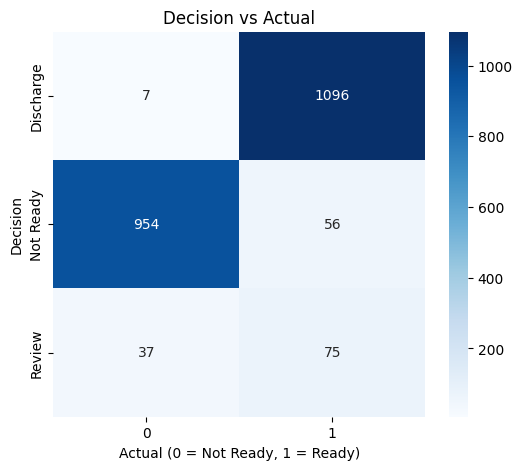

In [ ]:
import seaborn as sns

cm_df = pd.crosstab(
    test_df['decision'],
    y_test
)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Decision vs Actual")
plt.xlabel("Actual (0 = Not Ready, 1 = Ready)")
plt.ylabel("Decision")
plt.show()

Text(0.5, 0.98, 'Model Evaluation — ROC & Precision-Recall Curves')

Text(0.5, 1.0, 'ROC Curve — Discharge Readiness')

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'Precision-Recall Curve — Discharge Readiness')

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

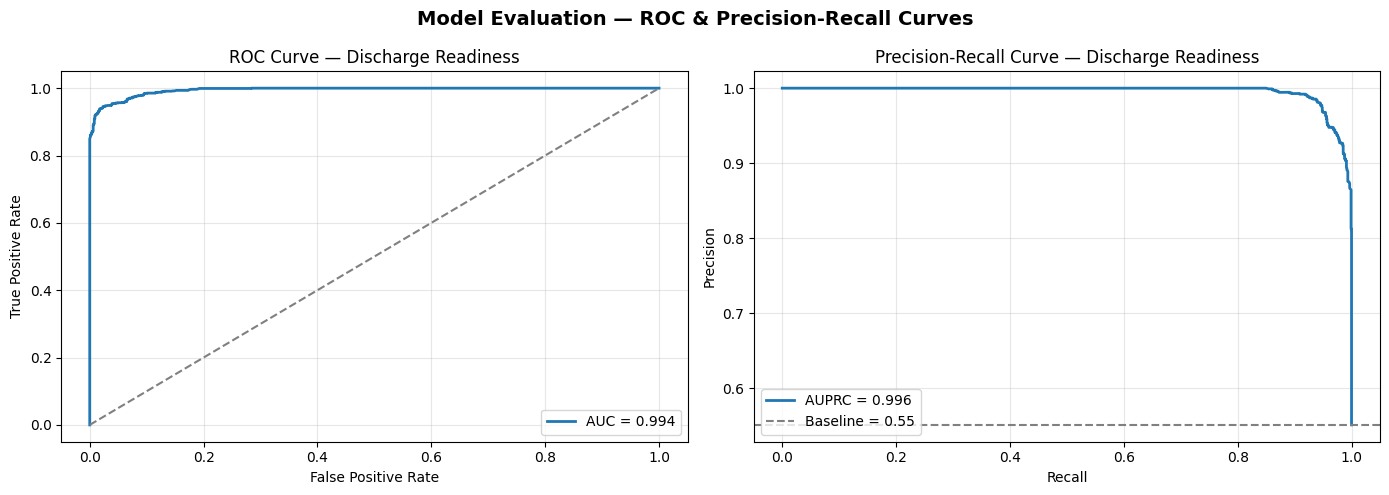

In [ ]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)

# Use calibrated probabilities (VERY IMPORTANT)
probs = y_calibrated

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Model Evaluation — ROC & Precision-Recall Curves",
    fontsize=14,
    fontweight="bold"
)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs)
axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_score(y_test, probs):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curve — Discharge Readiness")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, probs)
axes[1].plot(recall, precision, lw=2, label=f"AUPRC = {average_precision_score(y_test, probs):.3f}")
baseline = y_test.mean()
axes[1].axhline(baseline, color="gray", linestyle="--", label=f"Baseline = {baseline:.2f}")
axes[1].set_title("Precision-Recall Curve — Discharge Readiness")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})
importance_df = importance_df.sort_values(by='importance', ascending=False)
importance_df

,feature,importance
3,labs_normalized_score,1195
20,pain_mobility_ratio,1159
4,wound_healing_score,1133
2,mobility_score,1053
17,nurse_to_patient_ratio,723
5,procedure_duration_min,606
8,mobility_score_day1,555
16,avg_turnover_hours,531
9,social_barrier_flag,514
10,age,475


### <a id="shap-explanation-discharge-readiness"></a> SHAP Explanation for Discharge Readiness

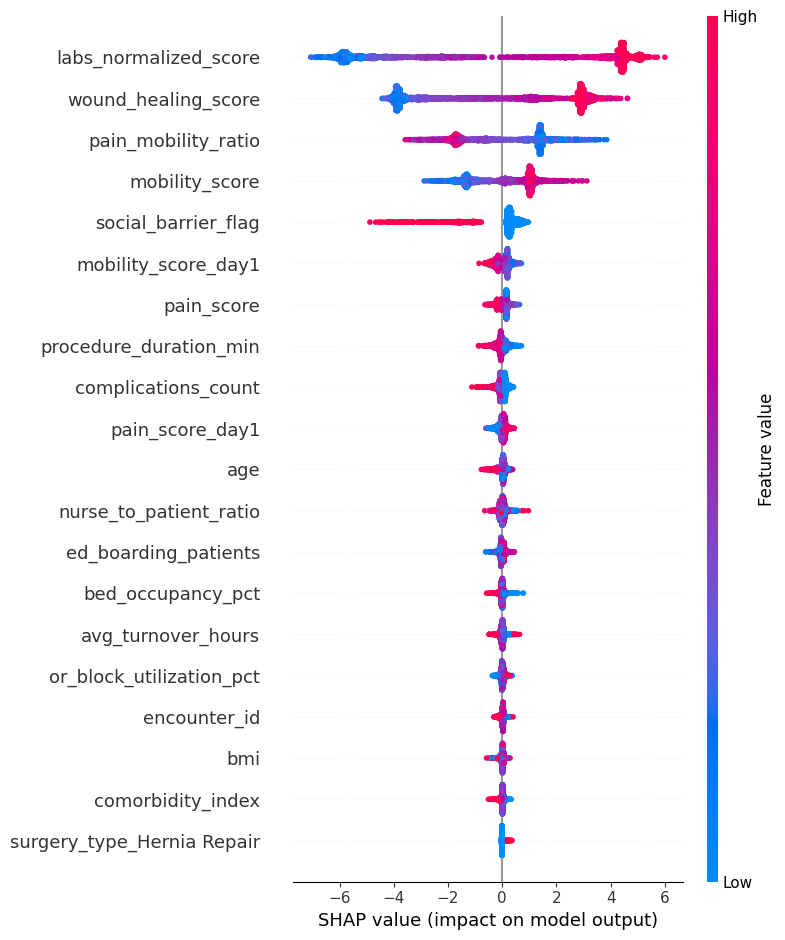

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

## <a id="model-2-los-prediction"></a> MODEL 2 - LOS Prediction

### <a id="admission-los-model"></a> 1. Admission LOS Model

In [ ]:
los_adm_df = master_df_2.drop_duplicates(subset=['encounter_id']).copy()

leakage_cols = [
    'discharge_ready_day',
    'length_from_admission',
    'recovery_score'
]
los_adm_df = los_adm_df.drop(columns=leakage_cols, errors='ignore')

target = 'actual_los_days'
X_adm = los_adm_df.drop(columns=[target, 'encounter_id'], errors='ignore')
y_adm = los_adm_df[target]

print(X_adm.shape, y_adm.shape)

(750, 46) (750,)


#### <a id="train-model-admission"></a> Train Model

In [ ]:
from lightgbm import LGBMRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X_adm, y_adm, test_size=0.3, random_state=42
)

model_adm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
model_adm.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000213 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 525, number of used features: 43
[LightGBM] [Info] Start training from score 8.826667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

LGBMRegressor(learning_rate=0.05, max_depth=6, n_estimators=300,
              random_state=42)

#### <a id="evaluation-admission"></a> Evaluation

In [ ]:
y_pred = model_adm.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("ADMISSION LOS MODEL")
print(f"MAE  : {mae:.3f} days")
print(f"RMSE : {rmse:.3f} days")
print(f"\nMean Actual LOS    : {y_test.mean():.2f}")
print(f"Mean Predicted LOS : {y_pred.mean():.2f}")

ADMISSION LOS MODEL
MAE  : 1.120 days
RMSE : 1.483 days

Mean Actual LOS    : 9.03
Mean Predicted LOS : 8.99


### <a id="part-2-post-operative-model"></a> PART 2 POST-OPERATIVE MODEL

In [ ]:
los_dyn_df = master_df_2.copy()
los_dyn_df = los_dyn_df.drop(
    columns=[
        'discharge_ready_day',
        'length_from_admission',
        'recovery_score'
    ],
    errors='ignore'
)

target = 'actual_los_days'
X_dyn = los_dyn_df.drop(columns=[target, 'encounter_id'], errors='ignore')
y_dyn = los_dyn_df[target]

print(X_dyn.shape, y_dyn.shape)

(7416, 46) (7416,)


In [ ]:
X_train_dyn, X_test_dyn, y_train_dyn, y_test_dyn = train_test_split(
    X_dyn, y_dyn, test_size=0.3, random_state=42
)

model_dyn = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=6,
    random_state=42
)
model_dyn.fit(X_train_dyn, y_train_dyn)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005861 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3275
[LightGBM] [Info] Number of data points in the train set: 5191, number of used features: 46
[LightGBM] [Info] Start training from score 10.410903
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

LGBMRegressor(learning_rate=0.03, max_depth=6, n_estimators=400,
              random_state=42)

#### <a id="evaluation-post-operative"></a> Evaluate

In [ ]:
y_pred_dyn = model_dyn.predict(X_test_dyn)
mae_dyn = mean_absolute_error(y_test_dyn, y_pred_dyn)
rmse_dyn = np.sqrt(mean_squared_error(y_test_dyn, y_pred_dyn))

print("POST-OPERATIVE LOS MODEL")
print(f"MAE  : {mae_dyn:.3f} days")
print(f"RMSE : {rmse_dyn:.3f} days")
print(f"\nMean Actual LOS    : {y_test_dyn.mean():.2f}")
print(f"Mean Predicted LOS : {y_pred_dyn.mean():.2f}")

POST-OPERATIVE LOS MODEL
MAE  : 0.347 days
RMSE : 0.485 days

Mean Actual LOS    : 10.35
Mean Predicted LOS : 10.37


<Figure size 1000x600 with 0 Axes>

<BarContainer object of 15 artists>

Text(0.5, 1.0, 'Top Features for LOS Prediction (Dynamic Model)')

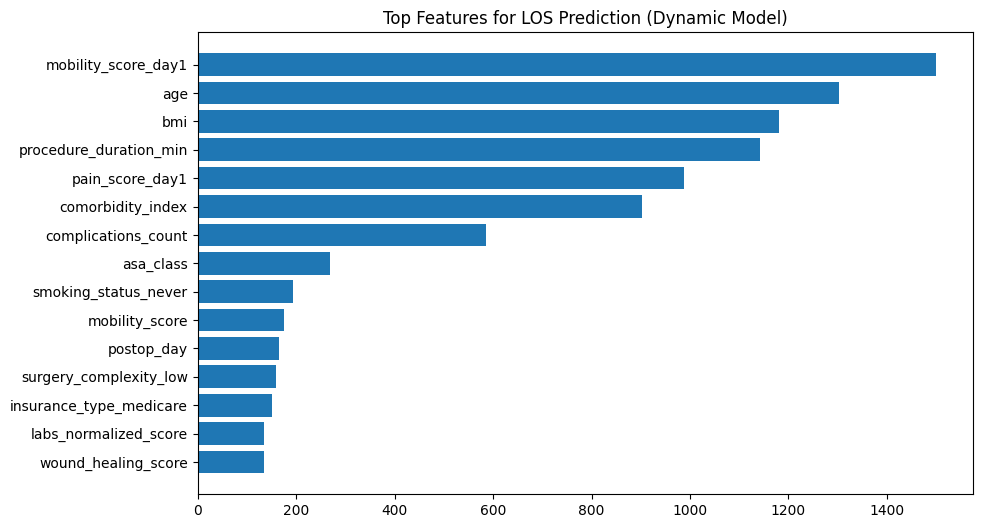

In [ ]:
feature_imp = pd.DataFrame({
    'feature': X_dyn.columns,
    'importance': model_dyn.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_imp['feature'][:15], feature_imp['importance'][:15])
plt.gca().invert_yaxis()
plt.title("Top Features for LOS Prediction (Dynamic Model)")
plt.show()

<Figure size 600x400 with 0 Axes>

(array([  2.,   1.,   0.,   2.,   1.,   4.,   0.,   4.,   4.,  16.,  23.,
         44.,  71., 143., 223., 321., 479., 378., 232., 125.,  69.,  43.,
         16.,  10.,   5.,   4.,   3.,   0.,   0.,   2.]),
 array([-3.04268616, -2.85930779, -2.67592943, -2.49255107, -2.3091727 ,
        -2.12579434, -1.94241598, -1.75903761, -1.57565925, -1.39228089,
        -1.20890252, -1.02552416, -0.8421458 , -0.65876743, -0.47538907,
        -0.29201071, -0.10863234,  0.07474602,  0.25812438,  0.44150275,
         0.62488111,  0.80825947,  0.99163784,  1.1750162 ,  1.35839456,
         1.54177293,  1.72515129,  1.90852965,  2.09190802,  2.27528638,
         2.45866474]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Residual Distribution')

Text(0.5, 0, 'Error (days)')

Text(0, 0.5, 'Frequency')

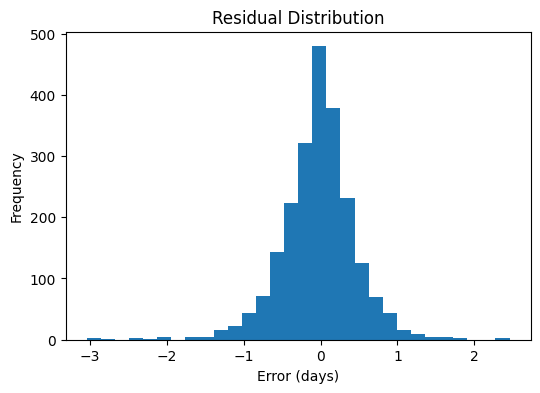

In [ ]:
residuals = y_test_dyn - y_pred_dyn
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Error (days)")
plt.ylabel("Frequency")
plt.show()

### <a id="actual-vs-predicted-los"></a> ACTUAL VS PREDICTED

<Figure size 600x600 with 0 Axes>

Text(0.5, 0, 'Actual LOS')

Text(0, 0.5, 'Predicted LOS')

Text(0.5, 1.0, 'Actual vs Predicted LOS (Dynamic)')

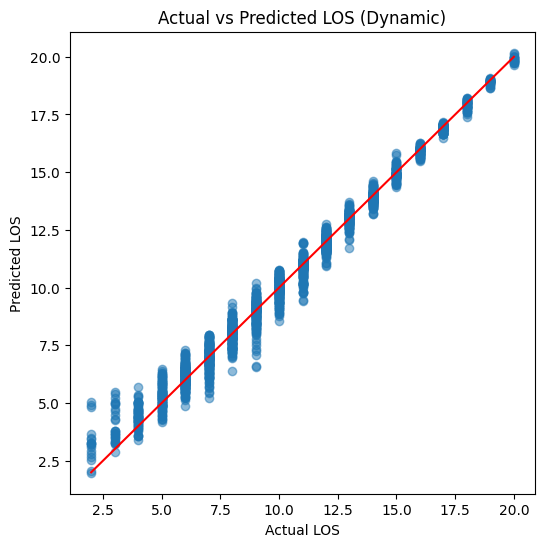

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_dyn, y_pred_dyn, alpha=0.5)
plt.plot(
    [y_test_dyn.min(), y_test_dyn.max()],
    [y_test_dyn.min(), y_test_dyn.max()],
    color='red'
)
plt.xlabel("Actual LOS")
plt.ylabel("Predicted LOS")
plt.title("Actual vs Predicted LOS (Dynamic)")
plt.show()

### <a id="los-final-summary"></a> Final Summary Evaluation — Length of Stay (LOS) Prediction

## <a id="model-3-readmission-risk"></a> MODEL 3 - 30-Day Readmission Risk

In [ ]:
# Encounter-level dataset
readmit_df = master_df_2.drop_duplicates(subset=['encounter_id']).copy()
print(readmit_df.shape)
readmit_df['readmission_30d'].value_counts()

(750, 51)


,count
readmission_30d,
0,551
1,199


In [ ]:
drop_cols = [
    # 'postop_day',
    # 'vitals_stability_score',
    'discharge_ready_day',
    'length_from_admission',
    'recovery_score'
]
readmit_df = readmit_df.drop(columns=drop_cols, errors='ignore')
readmit_df['readmission_30d'].value_counts(normalize=True)

,proportion
readmission_30d,
0,0.734667
1,0.265333


In [ ]:
### <a id="top-30-features-readmission"></a> top 30 features

Index(['mobility_score_day1', 'nurse_to_patient_ratio',
       'vitals_stability_score', 'or_block_utilization_pct', 'age',
       'labs_normalized_score', 'bed_occupancy_pct', 'wound_healing_score',
       'procedure_duration_min', 'bmi', 'avg_turnover_hours', 'pain_score',
       'pain_score_day1', 'mobility_score', 'pain_mobility_ratio',
       'actual_los_days', 'ed_boarding_patients', 'comorbidity_index',
       'complications_count', 'surgery_type_Hip Replacement',
       'surgery_type_Hernia Repair', 'insurance_type_self-pay',
       'gender_female', 'asa_class', 'smoking_status_never',
       'insurance_type_medicaid', 'insurance_type_commercial',
       'smoking_status_former', 'surgery_complexity_low',
       'surgery_type_Thyroidectomy', 'readmission_30d'],
      dtype='object')

In [ ]:
target = 'readmission_30d'
X = readmit_df.drop(columns=[target, 'encounter_id'], errors='ignore')
y = readmit_df[target]

print(X.shape, y.shape)
print("Readmission Rate:", y.mean())

(750, 30) (750,)
Readmission Rate: 0.2653333333333333


#### <a id="train-test-split-readmission"></a> Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
# pip install XGBOOST
readmit_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    class_weight='balanced',
    random_state=42
)



readmit_model.fit(X_train, y_train)

y_prob_readmit = readmit_model.predict_proba(X_test)[:, 1]

threshold = 0.30
y_pred_readmit = (y_prob_readmit >= threshold).astype(int)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 139, number of negative: 386
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1924
[LightGBM] [Info] Number of data points in the train set: 525, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

LGBMClassifier(class_weight='balanced', learning_rate=0.05, max_depth=6,
               n_estimators=300, random_state=42)

#### <a id="evaluation-readmission"></a> Evaluation

In [ ]:
print("TASK C — READMISSION RISK")
print(f"AUROC : {roc_auc_score(y_test, y_prob_readmit):.4f}")
print(f"AUPRC : {average_precision_score(y_test, y_prob_readmit):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_readmit, target_names=['No Readmit', 'Readmit']))

TASK C — READMISSION RISK
AUROC : 0.6258
AUPRC : 0.3769

Classification Report:

              precision    recall  f1-score   support

  No Readmit       0.78      0.75      0.76       165
     Readmit       0.38      0.43      0.41        60

    accuracy                           0.66       225
   macro avg       0.58      0.59      0.59       225
weighted avg       0.68      0.66      0.67       225



In [ ]:
#### <a id="decision-analysis-readmission"></a> Decision Analysis

Text(0.5, 1.0, '30-Day Readmission Risk')

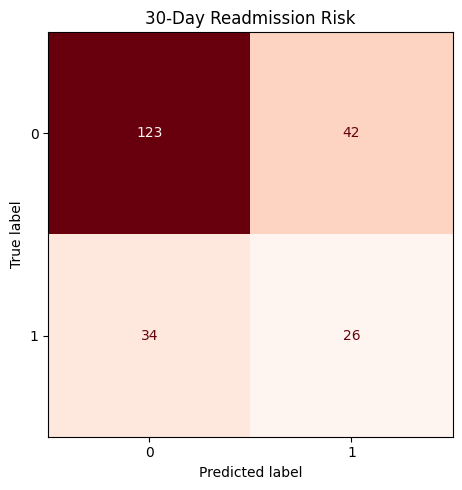

In [ ]:
# Confusion Matrix for Model 3
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_readmit)
).plot(
    ax=ax,
    colorbar=False,
    cmap="Reds"
)
ax.set_title("30-Day Readmission Risk")
plt.tight_layout()
plt.show()

In [ ]:
  def readmission_risk(prob):
      if prob >= 0.45:
          return "High Risk"
      elif prob >= 0.30:
          return "Medium Risk"
      else:
          return "Low Risk"

  test_df = X_test.copy()
  test_df['probability'] = y_prob_readmit
  test_df['risk_group'] = test_df['probability'].apply(readmission_risk)
  print(test_df['risk_group'].value_counts())

risk_group
Low Risk       157
High Risk       53
Medium Risk     15
Name: count, dtype: int64


In [ ]:
pd.crosstab(test_df['risk_group'], y_test)

readmission_30d,0,1
risk_group,,
High Risk,31,22
Low Risk,123,34
Medium Risk,11,4


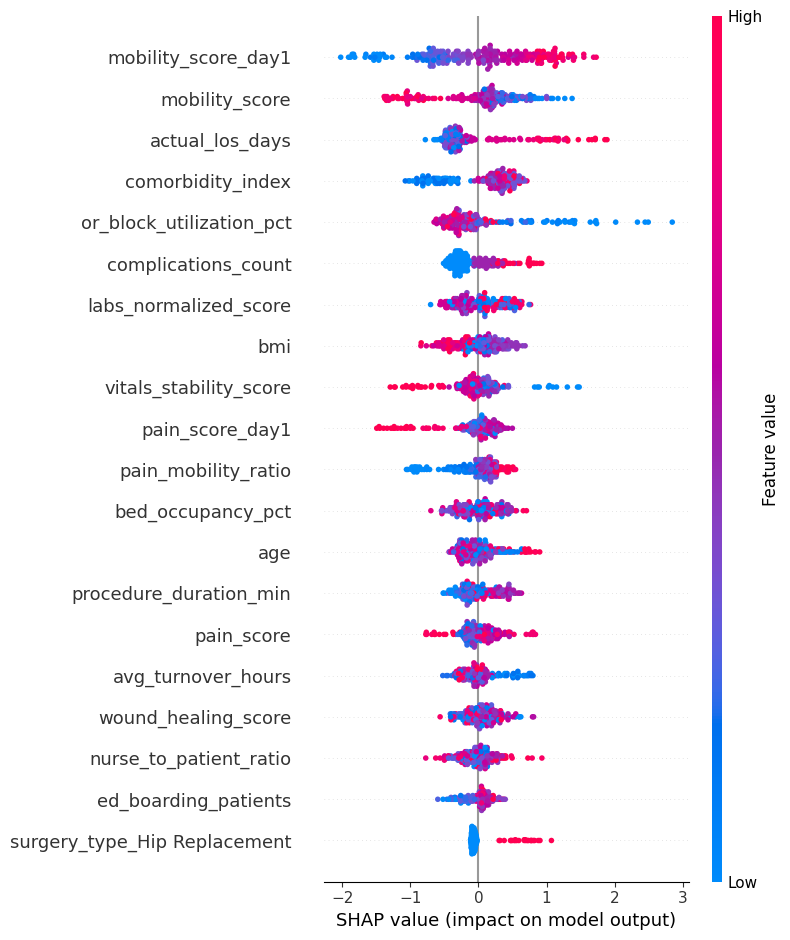

In [ ]:
import shap
explainer = shap.TreeExplainer(readmit_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

<Figure size 1000x600 with 0 Axes>

<BarContainer object of 15 artists>

Text(0.5, 1.0, 'Top Features for Readmission Risk')

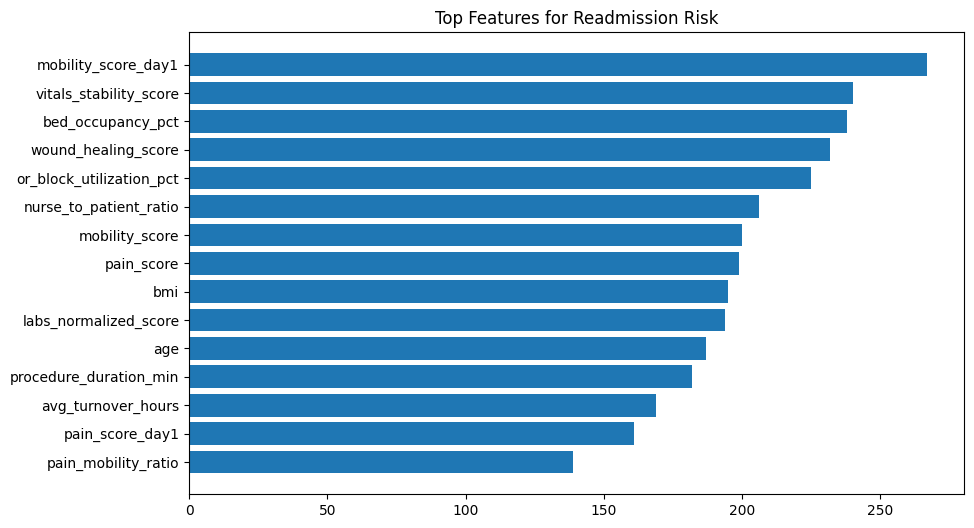

In [ ]:
feature_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': readmit_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_imp['feature'][:15], feature_imp['importance'][:15])
plt.gca().invert_yaxis()
plt.title("Top Features for Readmission Risk")
plt.show()

In [ ]:
feature_imp

,feature,importance
0,mobility_score_day1,267
2,vitals_stability_score,240
6,bed_occupancy_pct,238
7,wound_healing_score,232
3,or_block_utilization_pct,225
1,nurse_to_patient_ratio,206
13,mobility_score,200
11,pain_score,199
9,bmi,195
5,labs_normalized_score,194


Text(0.5, 0.98, 'Readmission Risk — ROC & Precision-Recall')

Text(0.5, 1.0, 'ROC Curve')

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'Precision-Recall Curve')

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

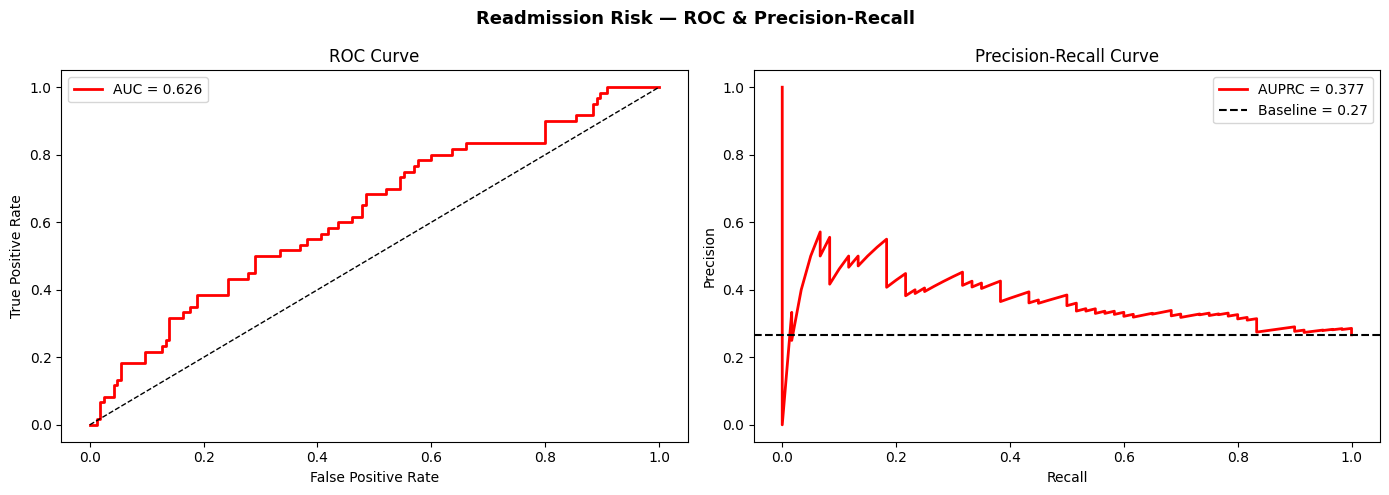

In [ ]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)

# ROC + Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Readmission Risk — ROC & Precision-Recall",
    fontsize=13,
    fontweight="bold"
)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_readmit)
axes[0].plot(fpr, tpr, lw=2, color='red', label=f"AUC = {roc_auc_score(y_test, y_prob_readmit):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_readmit)
axes[1].plot(recall, precision, lw=2, color='red', label=f"AUPRC = {average_precision_score(y_test, y_prob_readmit):.3f}")
axes[1].axhline(y_test.mean(), color="k", linestyle="--", label=f"Baseline = {y_test.mean():.2f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

<Axes: xlabel='importance', ylabel='feature'>

Text(0.5, 1.0, 'Top 15 Drivers of 30-Day Readmission Risk')

Text(0.5, 0, 'XGBoost Feature Importance')

Text(0, 0.5, 'Clinical/Operational Feature')

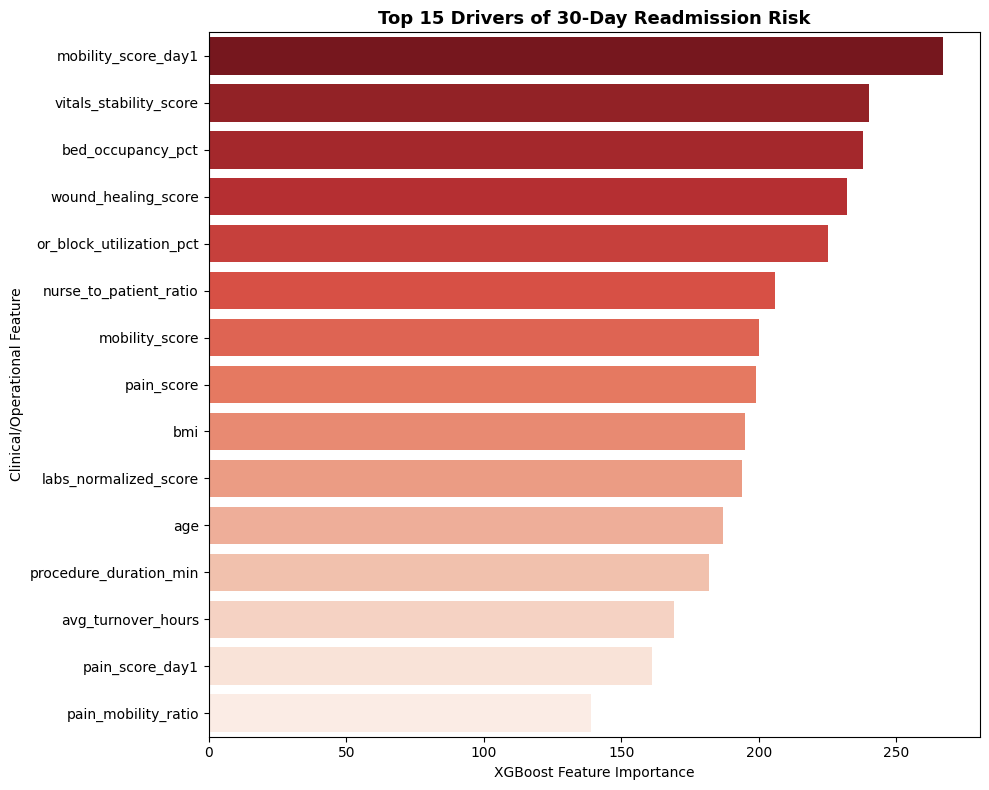

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Feature Importance for Readmission Model
readmit_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': readmit_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=readmit_importance.head(15),
    x='importance',
    y='feature',
    palette='Reds_r'
)
plt.title('Top 15 Drivers of 30-Day Readmission Risk', fontsize=13, fontweight='bold')
plt.xlabel('XGBoost Feature Importance')
plt.ylabel('Clinical/Operational Feature')
plt.tight_layout()
plt.show()

### <a id="readmission-model-final-summary"></a> Readmission Model — Final Summary

## <a id="task-4-clinical-intervention-recommendations"></a> Task 4: Clinical Intervention Recommendations

### <a id="summary-of-task-4-recommendations"></a> Summary of Task 4 Recommendations

In [ ]:
all_rec_list = []
for recs in recommendation_view['recommended_interventions']:
    all_rec_list.extend(recs.split(" | "))

rec_counts = pd.Series(all_rec_list).value_counts().sort_values(ascending=True)

# Plotting using horizontal bar chart
plt.figure(figsize=(10, 6))
rec_counts.plot(kind='barh', color='teal')

plt.title("Frequency of Clinical Recommendations (Test Set)", fontsize=14, fontweight='bold')
plt.xlabel("Count of Recommendations")
plt.ylabel("Intervention Type")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
def generate_recommendations(row):
    recommendations = []

    # 1. High Readmission Risk Intervention
    if row.get('readmission_prob', 0) > 0.4:
        recommendations.append("High-Touch Post-Discharge Follow-up (72 hrs)")
        if row.get('social_barrier_flag') == 1:
            recommendations.append("Social Work / Care Coordination Referral")

    # 2. LOS Reduction (Delayed Discharge Readiness)
    if row.get('discharge_ready_prob', 1) < 0.5:
        if row.get('mobility_score', 100) < 50:
            recommendations.append("Escalate Physical Therapy / Mobility Goals")
        if row.get('pain_score', 0) > 6:
            recommendations.append("Multimodal Pain Management Review")
        if row.get('care_plan_complete') == 0:
            recommendations.append("Prioritize Clinical Care Plan Completion")

    # 3. Operational Quality of Care
    icu = row.get('icu_required', 0)
    vitals = row.get('vitals_stability_score', 100)
    if icu == 1 and vitals < 70:
        recommendations.append("Critical Care Specialist Consultation")

    if not recommendations:
        recommendations.append("Continue Standard ERAS Protocol")

    return " | ".join(recommendations)


current_readmission_test_indices = X_test.index

discharge_model_excluded_cols = [
    'recovery_score', 'discharge_ready_day', 'actual_los_days',
    'length_from_admission', 'vitals_stability_score',
    'care_plan_complete', 'postop_day', 'discharge_ready_label'
]


full_discharge_X = master_df_2.drop(columns=discharge_model_excluded_cols, errors='ignore')


features_for_prediction_raw = full_discharge_X.loc[current_readmission_test_indices]


train_features = model.feature_name_


features_for_prediction = features_for_prediction_raw.reindex(columns=train_features, fill_value=0)


recommendation_view = master_df_2.loc[current_readmission_test_indices].copy()

recommendation_view['readmission_prob'] = y_prob_readmit


recommendation_view['discharge_ready_prob'] = model.predict_proba(features_for_prediction)[:, 1]


recommendation_view['recommended_interventions'] = recommendation_view.apply(generate_recommendations, axis=1)


display(recommendation_view[['readmission_prob', 'discharge_ready_prob', 'recommended_interventions']].head(10))

,readmission_prob,discharge_ready_prob,recommended_interventions
6915,0.018330,0.000012,Escalate Physical Therapy / Mobility Goals | M...
2819,0.014622,0.000009,Escalate Physical Therapy / Mobility Goals | P...
2892,0.027813,0.000009,Escalate Physical Therapy / Mobility Goals | P...
6058,0.455134,0.000013,High-Touch Post-Discharge Follow-up (72 hrs) |...
6485,0.185467,0.000011,Escalate Physical Therapy / Mobility Goals | M...
1312,0.102986,0.000009,Escalate Physical Therapy / Mobility Goals | P...
7008,0.043360,0.000018,Escalate Physical Therapy / Mobility Goals
6265,0.646620,0.000014,High-Touch Post-Discharge Follow-up (72 hrs) |...
2208,0.274512,0.000012,Escalate Physical Therapy / Mobility Goals | P...
4604,0.262891,0.000011,Escalate Physical Therapy / Mobility Goals | P...


<Figure size 1000x600 with 0 Axes>

<Axes: ylabel='None'>

Text(0.5, 1.0, 'Frequency of Clinical Recommendations (Test Set)')

Text(0.5, 0, 'Count')

Text(0, 0.5, 'Intervention Type')

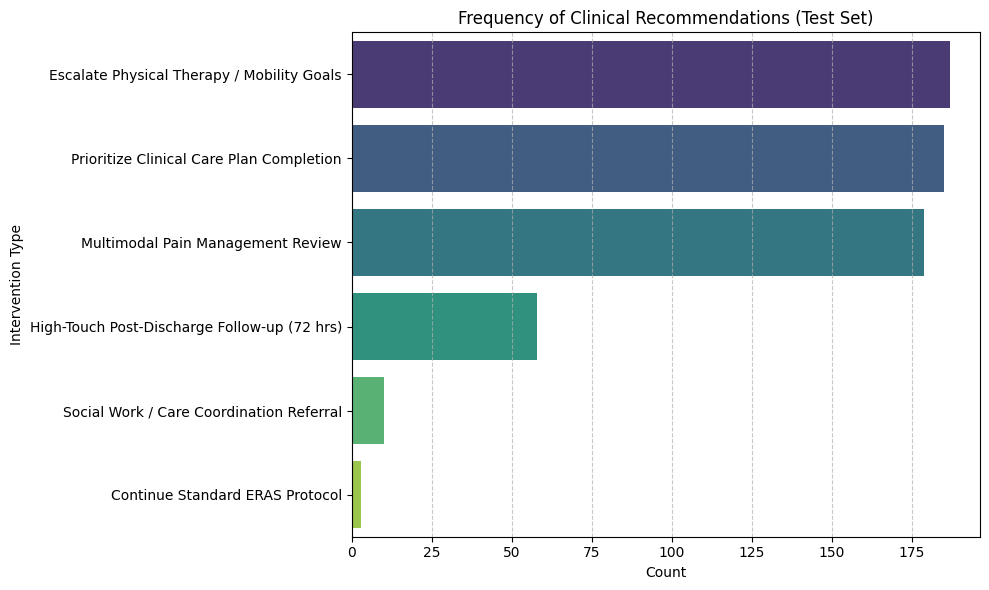

In [ ]:
all_rec_list = []
for recs in recommendation_view['recommended_interventions']:
    all_rec_list.extend(recs.split(" | "))

rec_counts = pd.Series(all_rec_list).value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=rec_counts.values, y=rec_counts.index, palette='viridis')
plt.title("Frequency of Clinical Recommendations (Test Set)")
plt.xlabel("Count")
plt.ylabel("Intervention Type")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Select and export the relevant clinical columns for validation
export_cols = [
    'readmission_prob',
    'discharge_ready_prob',
    'recommended_interventions'
]

output_filename = 'surgical_clinical_recommendations.csv'
recommendation_view[export_cols].to_csv(output_filename, index=True)
print(f'Successfully exported recommendations to {output_filename}')

Successfully exported recommendations to surgical_clinical_recommendations.csv


In [ ]:
recommendation_view.head()

,encounter_id,postop_day,vitals_stability_score,pain_score,mobility_score,labs_normalized_score,wound_healing_score,care_plan_complete,discharge_ready_label,procedure_duration_min,...,smoking_status_current,smoking_status_former,smoking_status_never,insurance_type_commercial,insurance_type_medicaid,insurance_type_medicare,insurance_type_self-pay,readmission_prob,discharge_ready_prob,recommended_interventions
6915,700,0,37.7,9.0,37.7,41.2,28.4,0,0,45,...,False,True,False,False,True,False,False,0.018330,0.000012,Escalate Physical Therapy / Mobility Goals | M...
2819,292,0,40.7,3.4,21.3,37.5,33.1,0,0,154,...,False,True,False,True,False,False,False,0.014622,0.000009,Escalate Physical Therapy / Mobility Goals | P...
2892,299,0,38.5,4.7,30.2,33.7,32.2,0,0,131,...,False,False,True,False,False,True,False,0.027813,0.000009,Escalate Physical Therapy / Mobility Goals | P...
6058,613,0,46.4,8.6,26.3,25.6,32.7,0,0,190,...,False,True,False,False,False,True,False,0.455134,0.000013,High-Touch Post-Discharge Follow-up (72 hrs) |...
6485,654,0,44.6,7.8,31.5,32.5,14.6,0,0,286,...,False,False,True,False,True,False,False,0.185467,0.000011,Escalate Physical Therapy / Mobility Goals | M...


In [ ]:
excel_file = '/content/surgical_clinical_recommendations.xlsx'
df_excel = pd.read_excel(excel_file)
display(df_excel.head())

,readmission_prob,discharge_ready_prob,recommended_interventions,icu_required,social_barrier_flag,care_plan_complete
0,0.693239,0.000185,High-Touch Post-Discharge Follow-up (72 hrs) |...,0,0,0
1,0.075884,0.000343,Escalate Physical Therapy / Mobility Goals | M...,1,0,1
2,0.021066,0.000160,Escalate Physical Therapy / Mobility Goals | M...,1,0,0
3,0.005296,0.000189,Prioritize Clinical Care Plan Completion,0,0,0
4,0.066155,0.000157,Escalate Physical Therapy / Mobility Goals | M...,0,1,0


## <a id="kernel-state"></a> Kernel State
No notable variables in the kernel yet.
Here are some of the files available in the kernel:
* /content/.config/gce
* /content/.config/default_configs.db
* /content/.config/config_sentinel
* /content/.config/.last_survey_prompt.yaml
* /content/.config/active_config
* /content/.config/.last_opt_in_prompt.yaml
* /content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
* /content/.config/.last_update_check.json
* /content/sample_data/README.md
* /content/sample_data/anscombe.json
* /content/sample_data/mnist_test.csv
* /content/sample_data/california_housing_train.csv
* /content/sample_data/mnist_train_small.csv
* /content/sample_data/california_housing_test.csv
* /content/drive/MyDrive/Getting started.pdf
* /content/drive/MyDrive/python_operations.gdoc
* /content/drive/MyDrive/DS_AnkushShrikhande (4).pdf
* /content/drive/MyDrive/Untitled spreadsheet (2).gsheet
* /content/drive/MyDrive/Untitled spreadsheet (1).gsheet
* /content/drive/MyDrive/Untitled spreadsheet.gsheet
* /content/drive/MyDrive/Google_Gemini_Overview.gslides
* /content/drive/MyDrive/Untitled presentation.gslides
* /content/drive/MyDrive/DS_AnkushShrikhande (3).pdf
* /content/drive/MyDrive/Classmates_Meetup_Collection.xlsx
* /content/drive/MyDrive/guest_info.xlsx
* /content/drive/MyDrive/guest_info.gsheet
* /content/drive/MyDrive/Classmates_Meetup_Collection.gsheet
* /content/drive/MyDrive/Meetup_program.gdoc
* /content/drive/MyDrive/AIIR_Intro.gdoc
* /content/drive/MyDrive/DS_AnkushShrikhande (2).pdf
* /content/drive/MyDrive/DS_AnkushShrikhande (1).pdf
* /content/drive/MyDrive/DS_AnkushShrikhande.pdf
* /content/drive/MyDrive/agentic_ai.gdoc
* /content/drive/MyDrive/DS_AnkushShrikhande_10yrs.pdf
* /content/drive/MyDrive/Wish list.gsheet
* /content/drive/MyDrive/Relieving cum experience Letter-Ankush Shrikhande.docx.pdf
* /content/drive/MyDrive/offlineaadhaar20250724110004622.zip
* /content/drive/MyDrive/MF Analysis.xlsx
* /content/drive/MyDrive/Untitled document.gdoc
* /content/drive/MyDrive/gr.gdoc
* /content/drive/MyDrive/DS_AnkushShrikhande_WU_10_yrs.pdf
* /content/drive/MyDrive/LLM_api.gdoc
* /content/drive/MyDrive/Ankush_Shrikhande_Data_Scientist_GenAI_10yrs.pdf
* /content/drive/MyDrive/To-do list.gsheet
* /content/drive/MyDrive/Oriana_Calculation.gsheet
* /content/drive/MyDrive/contact_hr.gsheet
* /content/.config/configurations/config_default
* /content/drive/MyDrive/Document/Resume_Ankush_New.docx
* /content/drive/MyDrive/Document/~$sume_Ankush_New.docx
* /content/drive/MyDrive/Document/Passport.pdf
* /content/drive/MyDrive/Ankusha/engagment_invitation_video.mp4
* /content/drive/MyDrive/Ankusha/engagment_invitation_video (1).mp4
* /content/drive/MyDrive/Ankusha/Engagement_Invitation_Card.jpg
* /content/drive/MyDrive/Ankusha/pic1.jpg
* /content/drive/MyDrive/Ankusha/pic2.jpg
* /content/drive/MyDrive/Ankusha/DSC01977.JPG
* /content/drive/MyDrive/Ankusha/DSC02029.JPG
* /content/drive/MyDrive/Ankusha/DSC02032.JPG
* /content/drive/MyDrive/Ankusha/DSC02033.JPG
* /content/drive/MyDrive/Ankusha/DSC01977 (1).JPG
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 4.51.47 PM.jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 4.51.48 PM.jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 4.51.48 PM (1).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 4.51.48 PM (2).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 4.51.49 PM.jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 4.51.49 PM (1).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 4.51.49 PM (2).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 4.51.49 PM (3).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 4.51.50 PM.jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 4.51.50 PM (1).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 4.51.50 PM (2).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 4.51.51 PM.jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 4.51.51 PM (1).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 5.54.05 PM.jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 5.54.05 PM (1).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 5.54.06 PM.jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 5.54.06 PM (1).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 5.54.06 PM (2).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 5.54.06 PM (3).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 7.02.09 PM.jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 7.02.09 PM (1).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 7.02.09 PM (2).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 7.02.09 PM (3).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 7.02.09 PM (4).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 7.02.09 PM (5).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 7.02.09 PM (6).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 7.02.09 PM (7).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 7.02.09 PM (8).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 7.02.09 PM (9).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 7.02.09 PM (10).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 7.02.09 PM (11).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-26 at 7.02.09 PM (12).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Video 2021-06-26 at 7.25.41 PM.mp4
* /content/drive/MyDrive/Ankusha/IMG_20210625_133033.jpg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-25 at 3.14.53 PM.jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-25 at 3.14.54 PM.jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-25 at 3.14.55 PM.jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-25 at 3.14.55 PM (1).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-25 at 3.14.56 PM.jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-25 at 3.14.57 PM.jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-25 at 3.14.58 PM.jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-25 at 3.14.58 PM (1).jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-25 at 3.14.59 PM.jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-25 at 4.46.49 PM.jpeg
* /content/drive/MyDrive/Ankusha/WhatsApp Image 2021-06-25 at 1.29.50 PM.jpeg
* /content/drive/MyDrive/Ankusha/engament_video.mp4
* /content/drive/MyDrive/Ankusha/engament_video_2.mp4
* /content/drive/MyDrive/Ankusha/WhatsApp Unknown 2021-06-28 at 9.08.24 PM.zip